In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from notebook_setup import *

# Overview of the training dataset

This file presents an overview of the training dataset, focusing on the profiles of Alptis clients and brokers, as well as their consumption patterns and reviews.

##### Import libraries and loading the data

In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.Visualisation import plot_hist_top_k
from src.utils import TransformData
from src.data_processing.data_load import data_loading

##### Analysis of Portfolio

# Portfolio analysis

### Client profile analysis

In [4]:
# Load data from training set
df_portefeuille, df_consommations, df_reclamations, df_interactions, df_impayes = data_loading("training")

# Data formatting
df_portefeuille['client_code'] = df_portefeuille['client_code'].astype(str)
df_portefeuille['client_code_postal'] = df_portefeuille['client_code_postal'].astype(str).str.zfill(5)
df_portefeuille['client_departement'] = df_portefeuille['client_departement'].astype(str).str.zfill(2)
df_portefeuille['client_departement_avant_changement_12_mois'] = df_portefeuille['client_departement_avant_changement_12_mois'].astype(str)
df_portefeuille['client_a_garantie_prevoyance'] = df_portefeuille['client_a_garantie_prevoyance'].astype(str)
df_portefeuille['client_est_contrat_madelin'] = df_portefeuille['client_est_contrat_madelin'].astype(str)
df_portefeuille['courtier_est_escompte'] = df_portefeuille['courtier_est_escompte'].astype(str)
df_portefeuille['client_a_conjoint'] = df_portefeuille['client_a_conjoint'].astype(str)
df_portefeuille['courtier_code_partenaire'] = df_portefeuille['courtier_code_partenaire'].astype(str)
df_portefeuille['courtier_code_apporteur'] = df_portefeuille['courtier_code_apporteur'].astype(str)
df_portefeuille['courtier_code_avant_changement_12_mois'] = df_portefeuille['courtier_code_avant_changement_12_mois'].astype(str)
df_portefeuille['client_nb_enfants'] = df_portefeuille['client_nb_enfants'].astype(int)
df_portefeuille['client_nb_assures_contrat'] = df_portefeuille['client_nb_assures_contrat'].astype(int)
df_consommations['annee_mois_paiement'] = pd.to_datetime(df_consommations['annee_mois_paiement'], format='%Y-%m') + pd.offsets.MonthEnd(1)

In [5]:
df_client = df_portefeuille[[c for c in df_portefeuille.columns if c.startswith("client")]]
print(f"Number of clients in Alptis porfolio: {len(df_client)}")

Number of clients in Alptis porfolio: 132576


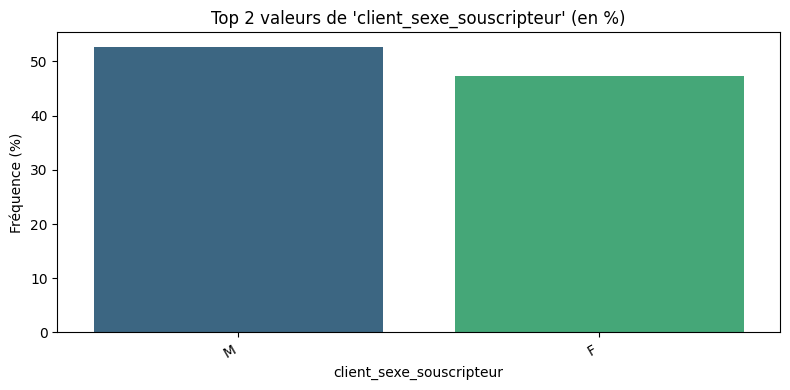

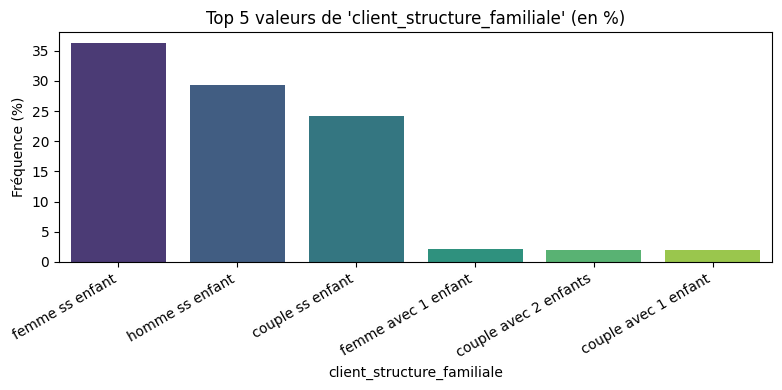

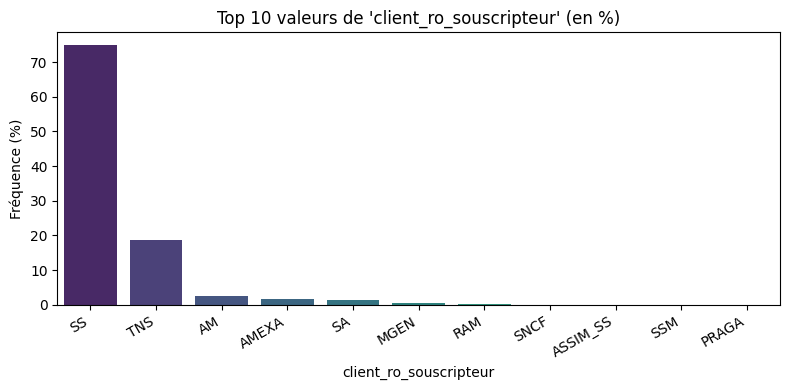

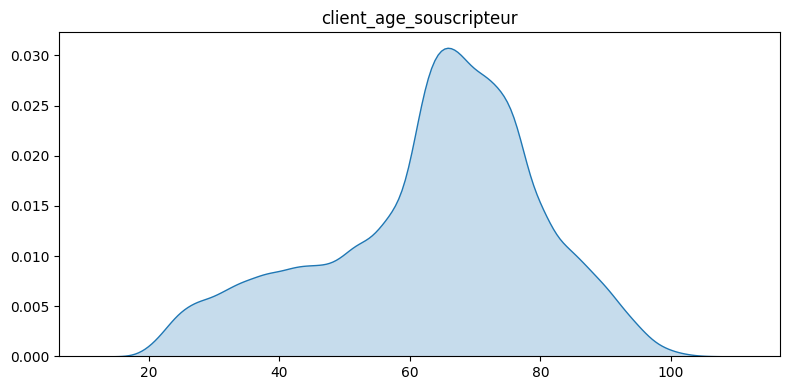

In [6]:
#plot_hist_top_k(df_client, ["client_sexe_souscripteur", "client_a_conjoint"], k=2)
plot_hist_top_k(df_client, ["client_sexe_souscripteur"], k=2)
plot_hist_top_k(df_client, ["client_structure_familiale"], k=5)
#plot_hist_top_k(df_portefeuille_cleaned, ["client_departement", "client_ro_souscripteur", "client_nb_enfants"], k=10)
plot_hist_top_k(df_client, ["client_ro_souscripteur"], k=10)

continuous_var= ["client_age_souscripteur"]
plt.figure(figsize=(8, 4))
for c,var in enumerate(continuous_var):
  plt.subplot(1, 1, c+1)
  sns.kdeplot(data=df_client[continuous_var], x=var, fill=var)
  plt.title(str(var))
  plt.xlabel("")
  plt.ylabel("")

plt.tight_layout()


/home/onyxia/work/Alptis-churn-prediction/src/utils/TransformData.py:299: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="classe_age", columns=col_sexe,


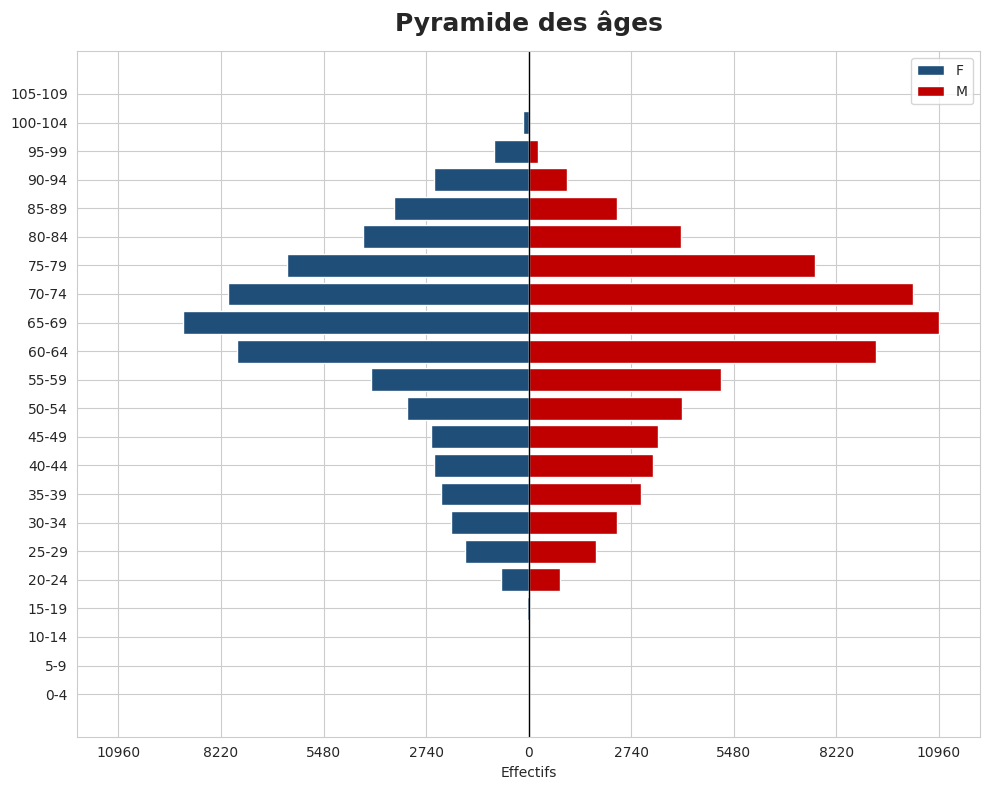

In [7]:
# Age pyramid
TransformData.plot_pyramide_ages(df=df_client, col_age="client_age_souscripteur", col_sexe= 'client_sexe_souscripteur')

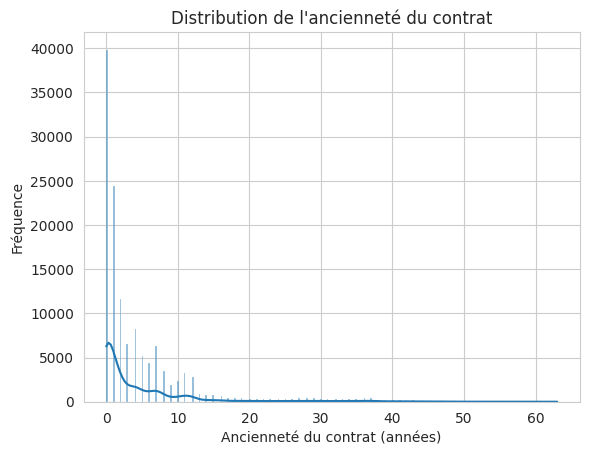

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_portefeuille["client_anciennete_contrat_annees"], kde=True)
plt.xlabel("Ancienneté du contrat (années)")
plt.ylabel("Fréquence")
plt.title("Distribution de l'ancienneté du contrat")
plt.show()


**Analysis of customer profile**
-   Le portefeuille de client Alptis en 2023 se compose de presqu'autant de femmes que d'hommes
-   La majorité des clients (+ 80%) est composée d'adultes, qu'ils soient célibataires ou en couple, n'ayant aucun enfant. 
-   Les 3/4 des clients dépendent du régime de la Sécurité sociale, 20% du régime des travailleur non salariés. Pour le reste (5 %), ils disposent de régimes spéciaux.
-   La distribution des âges des clients est fortement concentrée à droite, au delà de 50 ans. L'âge moyen est de 63 ans et 75 % des souscripteurs a plus de 54 ans.
-   [RECO] Comment aller chercher des profils plus jeunes ?

**Relevance of graphs**
-   J'ai retiré le graphique présentant le top 10 des départements avec le plus de client. Info mieux illustré à travers une carte
-   J'ai retiré le graphique du top du nombre d'enfants assurés - Il serait plus pertinent de savoir le nombre d'assuré chez les adultes ayant au moins un enfant (voir section souscription). Je comprends mieux le graphique de Kelly avec tous les camemberts. L'enseignement qu'on peut en tirer c'est que les clients ayant plus d'une personne dans leur foyer assurent systématiquement les autres membres du foyer sauf quelques rares cas.
-   J'ai retiré le graphique client_a_conjoint : La comparaison peut prêter à confusion. la classe ==1 concerne les clients qui ont nécessairement un conjoint. La classe ==0 comprends en plus des clients avec conjoint, d'autres qui vivent seuls avec ou sans enfants. On aurait tendance à comparer deux catégories qui ne sont pas comparables. Il serait plus intéressant de regarder parmi les clients avec conjoint, quelle proportion de conjoints assurés. 

### Analyse des zones tarifaires

In [9]:
print(f"Nombre de zones tarifaires: {df_portefeuille["client_zone_tarifaire"].nunique()} \nNombre de types de zone tarifaire:  {df_portefeuille["client_type_zone_tarifaire"].nunique()}")

Nombre de zones tarifaires: 173 
Nombre de types de zone tarifaire:  51


-------------Répartion des types de zone tarifaires dans le Top 15 code postal ----------------


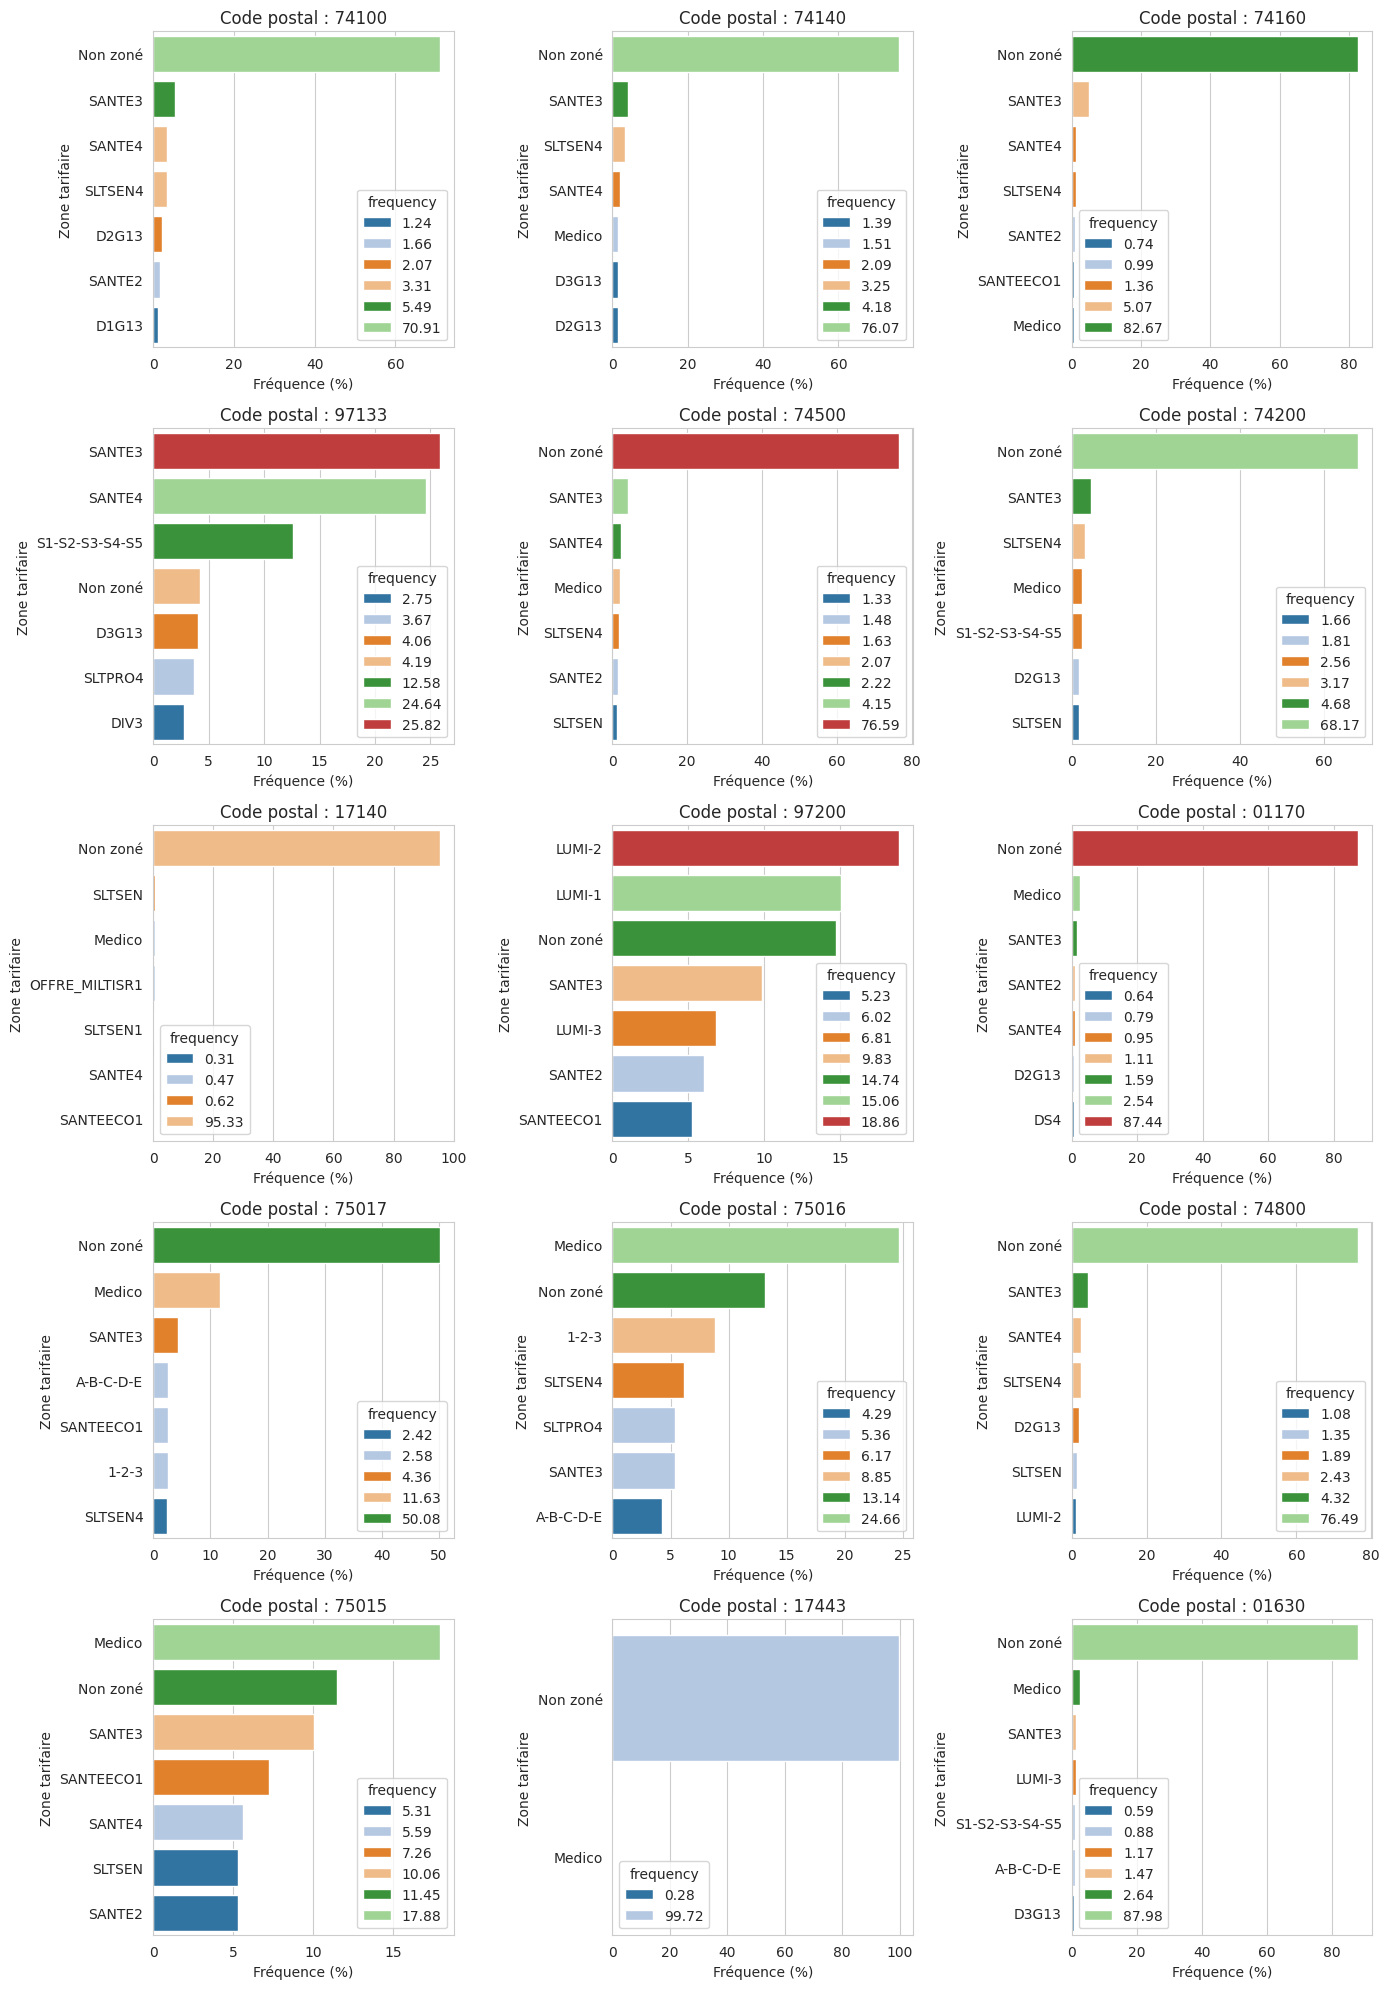

In [10]:
print("-------------Répartion des types de zone tarifaires dans le Top 15 code postal ----------------")
# Top 15 codes postaux les plus représentés
top_cps = df_portefeuille["client_code_postal"].astype(str).value_counts().index[:15]

top_zone_per_cp = {}

plt.figure(figsize=(14, 20))

for c, cp in enumerate(top_cps, start=1):

    df_cp = (
        df_portefeuille.loc[df_portefeuille["client_code_postal"].astype(str) == cp,
                            "client_type_zone_tarifaire"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )

    # Renommage propre des colonnes
    df_cp.columns = ["client_type_zone_tarifaire", "frequency"]

    # Sauvegarde du top 1
    top_zone_per_cp[cp] = df_cp.iloc[0]["client_type_zone_tarifaire"]

    # subplot
    plt.subplot(5, 3, c)

    sns.barplot(
        data=df_cp.head(7),
        x="frequency",
        y="client_type_zone_tarifaire",
        hue="frequency",
        palette="tab20"
    )

    plt.title(f"Code postal : {cp}")
    plt.xlabel("Fréquence (%)")
    plt.ylabel("Zone tarifaire")

plt.tight_layout()
plt.show()


Un même code postal ou département peut se retrouver dans différents types de zone tarifaires. Il faudrait comprendre plus en détail comme les zones tarifaires sont établies si ça ne dépend pas que du code postal.

### Client subscription analysis

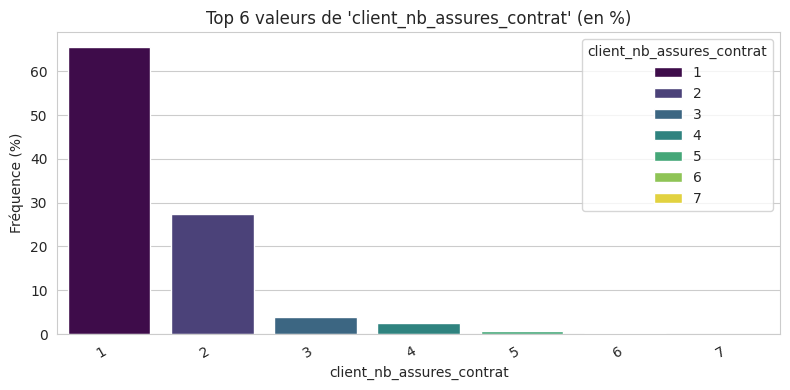

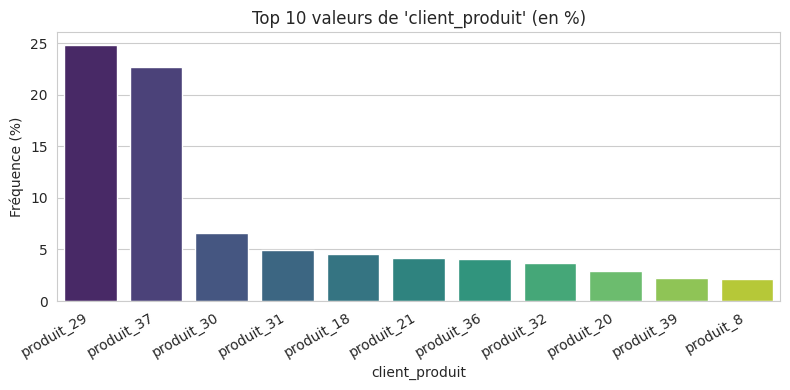

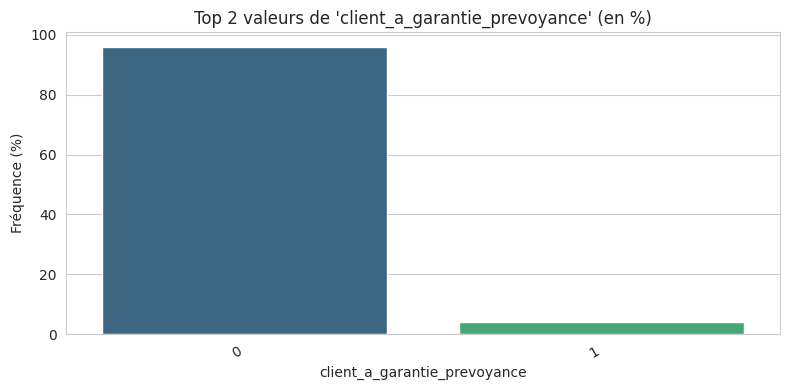

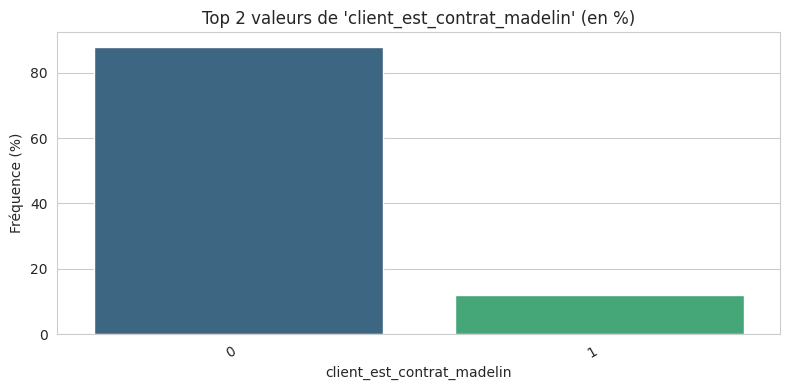

In [11]:
#analyse des package de subscription les plus populaire chez les clients 
# (contrat madellin, nb assures, produit gestion, ...)
plot_hist_top_k(df_portefeuille, ["client_nb_assures_contrat"], k=6)
plot_hist_top_k( df_portefeuille, ["client_produit"], k=10)
plot_hist_top_k(df_portefeuille, ['client_a_garantie_prevoyance', 'client_est_contrat_madelin'], k=2)

#Commentaire on subscription

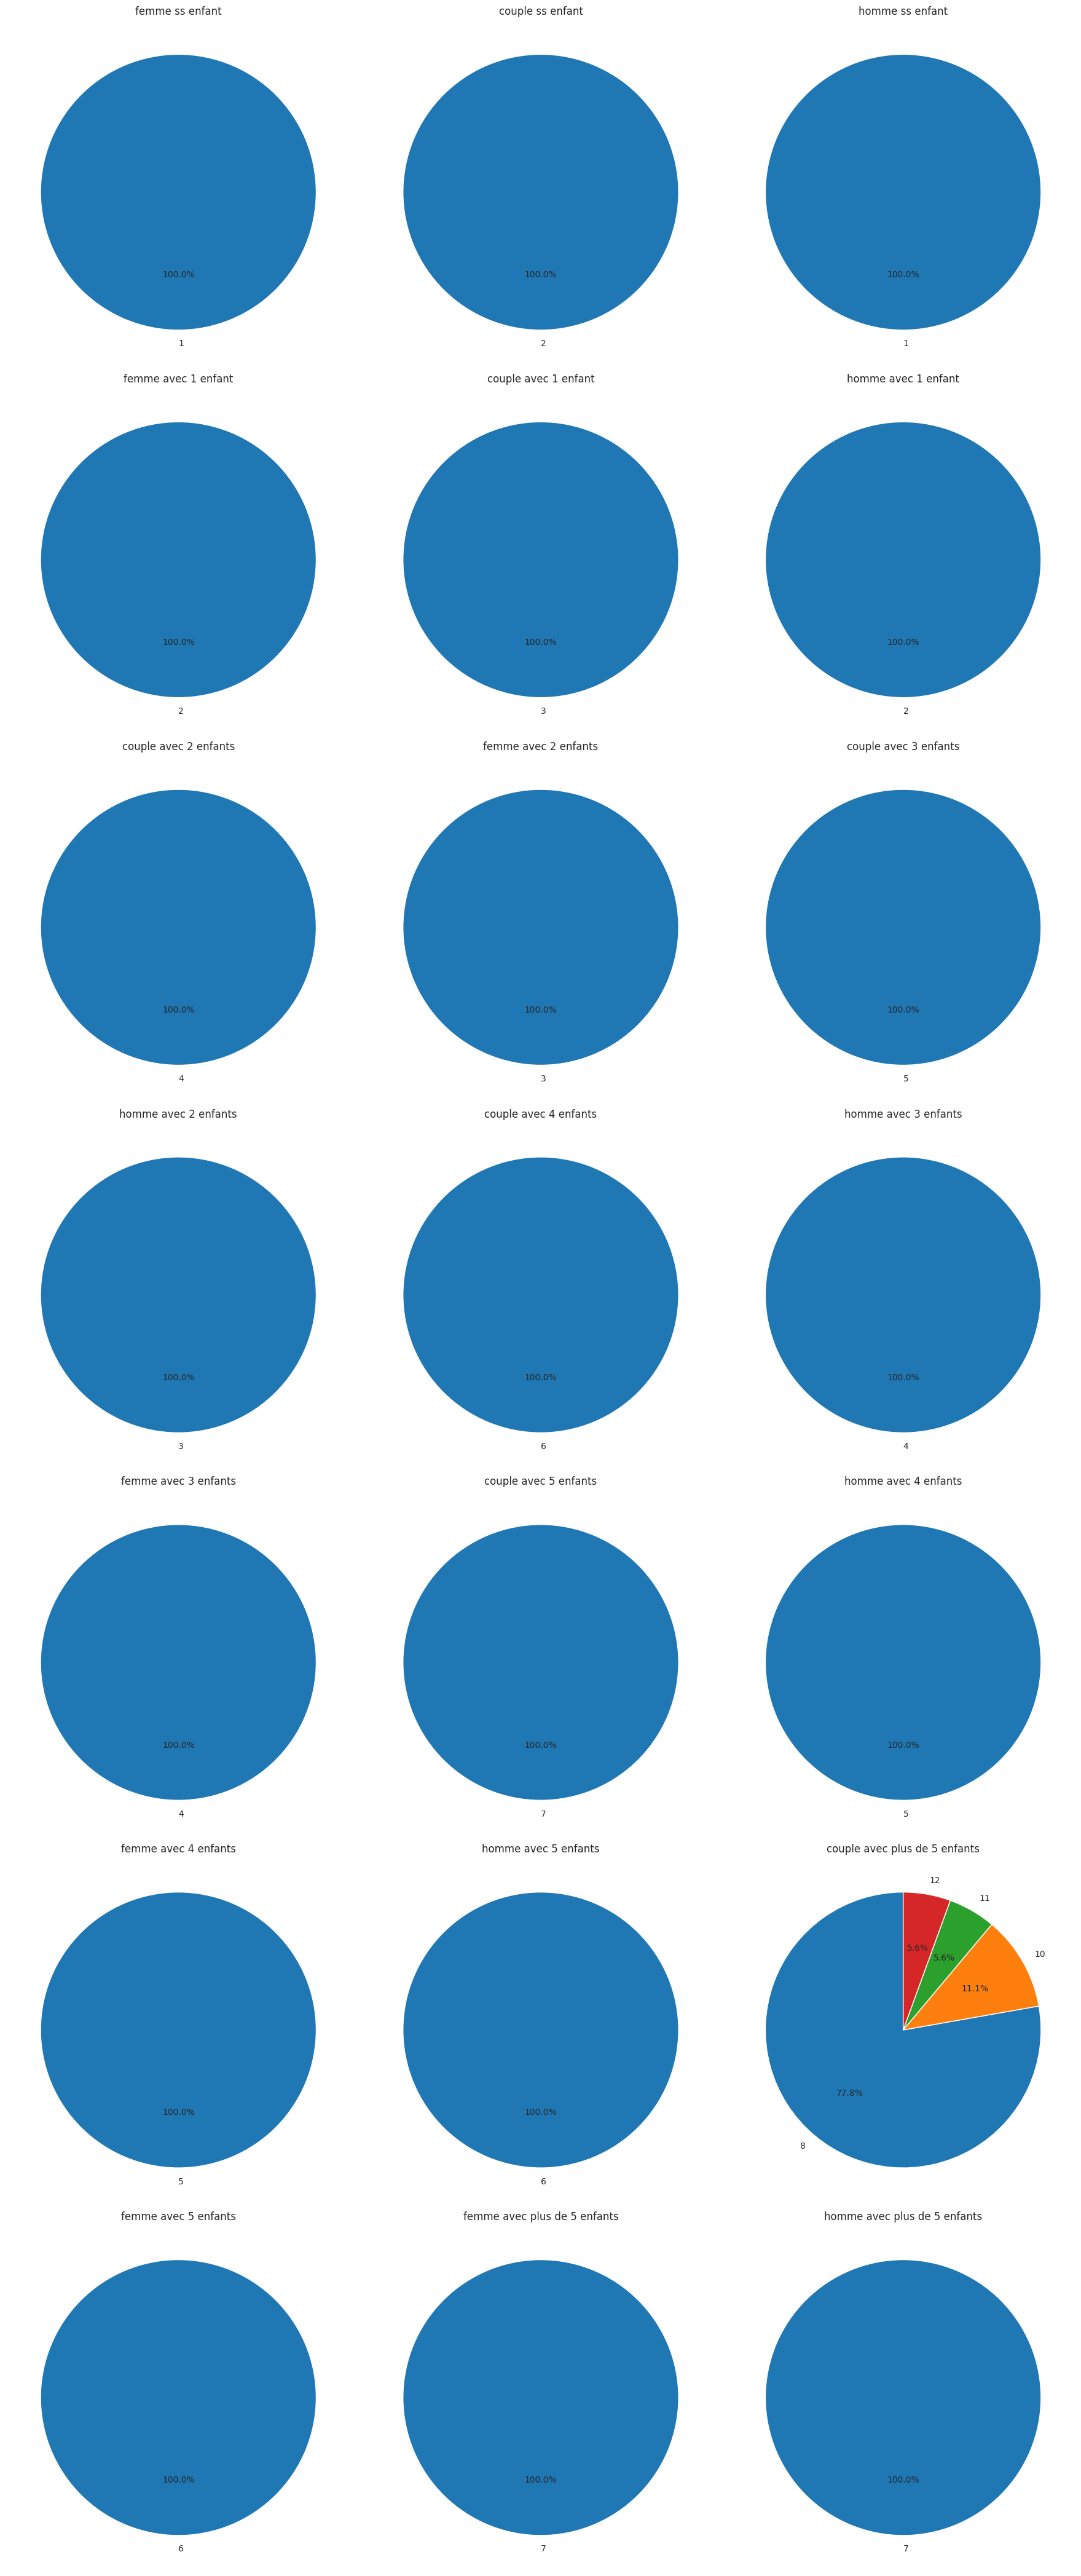

In [12]:
#Analyse du type de contrat souscrit selon profil familial

import math

# Liste des situations
situations = df_portefeuille["client_structure_familiale"].dropna().unique()
n = len(situations)

# Définir automatiquement une grille adaptée
cols = 3                                  # 3 camemberts par ligne (modifiable)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
axes = axes.flatten()                     # pour itérer facilement

for i, situation in enumerate(situations):
    
    df_sit = df_portefeuille[df_portefeuille["client_structure_familiale"] == situation]
    counts = df_sit["client_nb_assures_contrat"].value_counts().sort_index()

    axes[i].pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f"{situation}")

# Cacher les axes restants si la grille est plus grande que le nombre de situations
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### Courtier Analysis

In [13]:
print(f"Number of brokers in Alptis portfolio: {df_portefeuille["courtier_code_partenaire"].nunique()}")

Number of brokers in Alptis portfolio: 4862


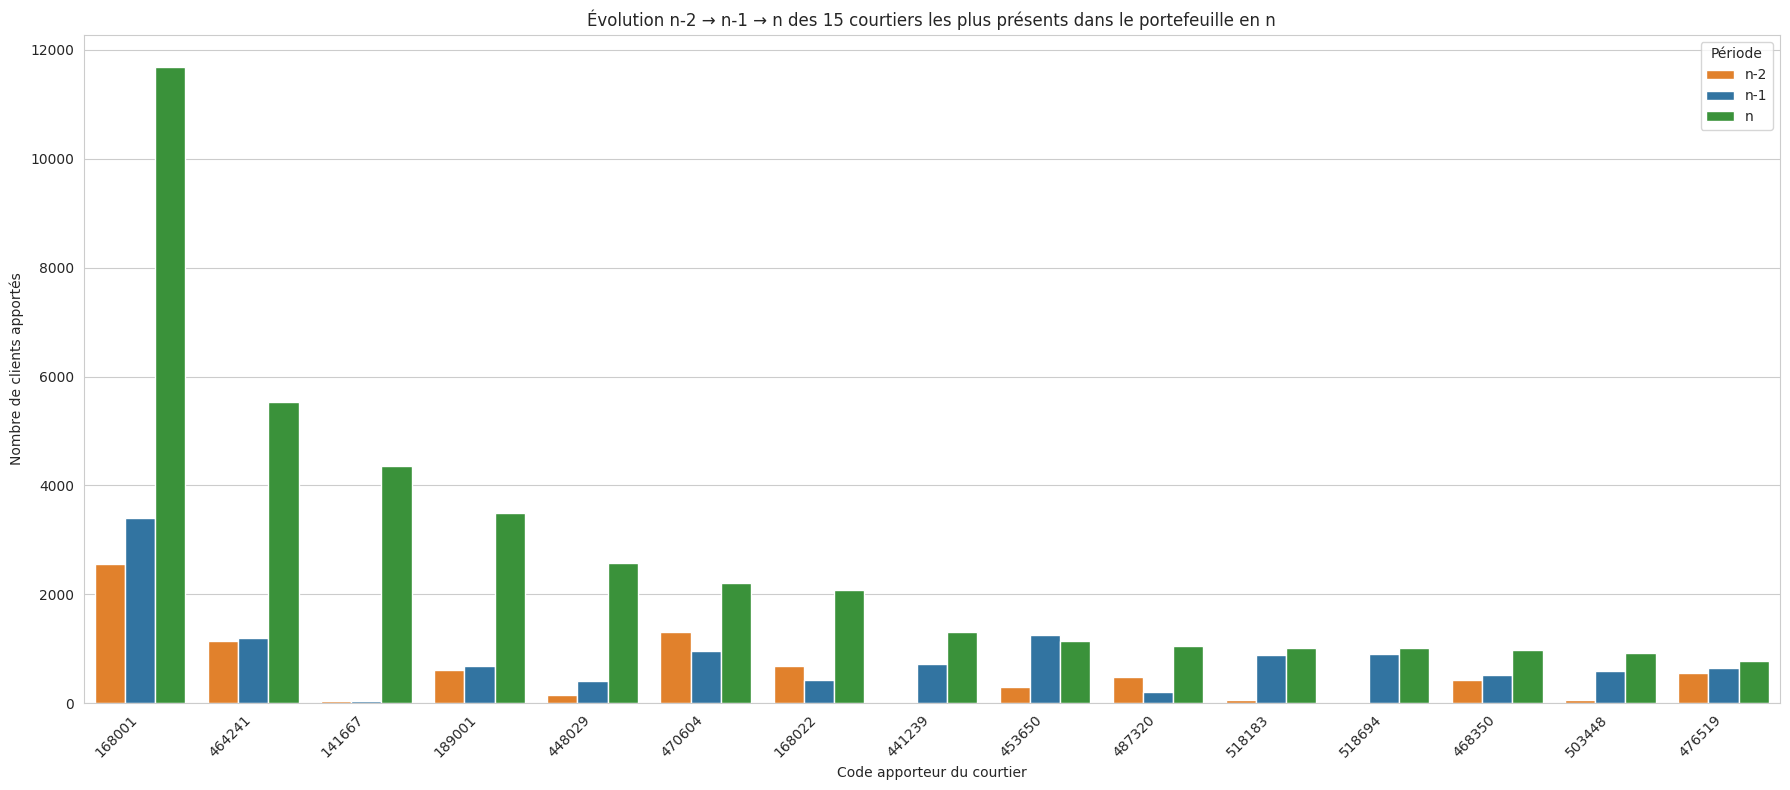

In [14]:
#Evolution des courtier entre n-2 et n

# --------------------------------------
# 1) Top 15 des courtiers en année N
# --------------------------------------
popularite_N = df_portefeuille["courtier_code_apporteur"].value_counts()

top15_codes = popularite_N[:15].index.tolist()

# --------------------------------------
# 2) Extraire n-2 et n-1 pour ces courtiers
# --------------------------------------
df_evol = df_portefeuille[
    df_portefeuille["courtier_code_apporteur"].isin(top15_codes)
][[
    "courtier_code_apporteur",
    "courtier_nb_affaires_n_moins2",
    "courtier_nb_affaires_n_moins1"
]]

df_evol = df_evol.drop_duplicates(subset=["courtier_code_apporteur"])

# --------------------------------------
# 3) Ajouter l'année N (popularité)
# --------------------------------------
df_evol["courtier_nb_affaires_n"] = df_evol["courtier_code_apporteur"] \
                                        .map(popularite_N)

# --------------------------------------
# 4) Trier selon N (ordre décroissant)
# --------------------------------------
df_evol_sorted = df_evol.sort_values(
    by="courtier_nb_affaires_n", ascending=False
)

order_x = df_evol_sorted["courtier_code_apporteur"].tolist()

# --------------------------------------
# 5) Reformater pour seaborn
# --------------------------------------
df_long = df_evol_sorted.melt(
    id_vars="courtier_code_apporteur",
    value_vars=[
        "courtier_nb_affaires_n_moins2",
        "courtier_nb_affaires_n_moins1",
        "courtier_nb_affaires_n"
    ],
    var_name="periode",
    value_name="nb_clients"
)

df_long["periode"] = df_long["periode"].replace({
    "courtier_nb_affaires_n_moins2": "n-2",
    "courtier_nb_affaires_n_moins1": "n-1",
    "courtier_nb_affaires_n": "n"
})

periode_order = ["n-2", "n-1", "n"]
palette = {"n-2": "#ff7f0e", "n-1": "#1f77b4", "n": "#2ca02c"}  # orange / bleu / vert

# --------------------------------------
# 6) Plot final
# --------------------------------------
plt.figure(figsize=(18, 8))

sns.barplot(
    data=df_long,
    x="courtier_code_apporteur",
    y="nb_clients",
    hue="periode",
    hue_order=periode_order,
    palette=palette,
    order=order_x
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Code apporteur du courtier")
plt.ylabel("Nombre de clients apportés")
plt.title("Évolution n-2 → n-1 → n des 15 courtiers les plus présents dans le portefeuille en n")
plt.legend(title="Période")

plt.tight_layout()
plt.show()


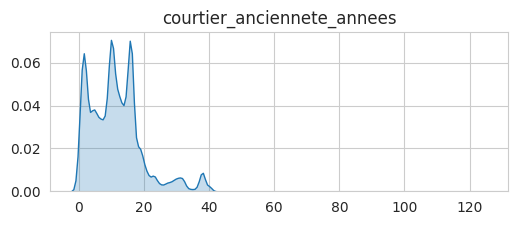

In [15]:
continuous_var= ["courtier_anciennete_annees"]
plt.figure(figsize=(10, 12))
for c,var in enumerate(continuous_var):
  plt.subplot(6, 2, c+1)
  sns.kdeplot(data=df_portefeuille[continuous_var], x=var, fill=var)
  plt.title(str(var))
  plt.xlabel("")
  plt.ylabel("")

plt.tight_layout()

# Consommation Analysis

In [16]:
# Spliting categorical numerical variables
list_categorical = df_consommations.select_dtypes(include=["object","bool"]).columns.to_list()
list_numerical = df_consommations.select_dtypes(exclude=["object","bool", "datetime"]).columns.to_list()
list_datetime = df_consommations.select_dtypes(include=["datetime"]).columns.to_list()

# Aggregate the dataset by datetime
df_conso_datetime = df_consommations[list_datetime + list_numerical].groupby(by='annee_mois_paiement').agg('sum').reset_index()
df_conso_datetime['month-year'] = df_conso_datetime['annee_mois_paiement'].dt.to_period('M').astype(str)


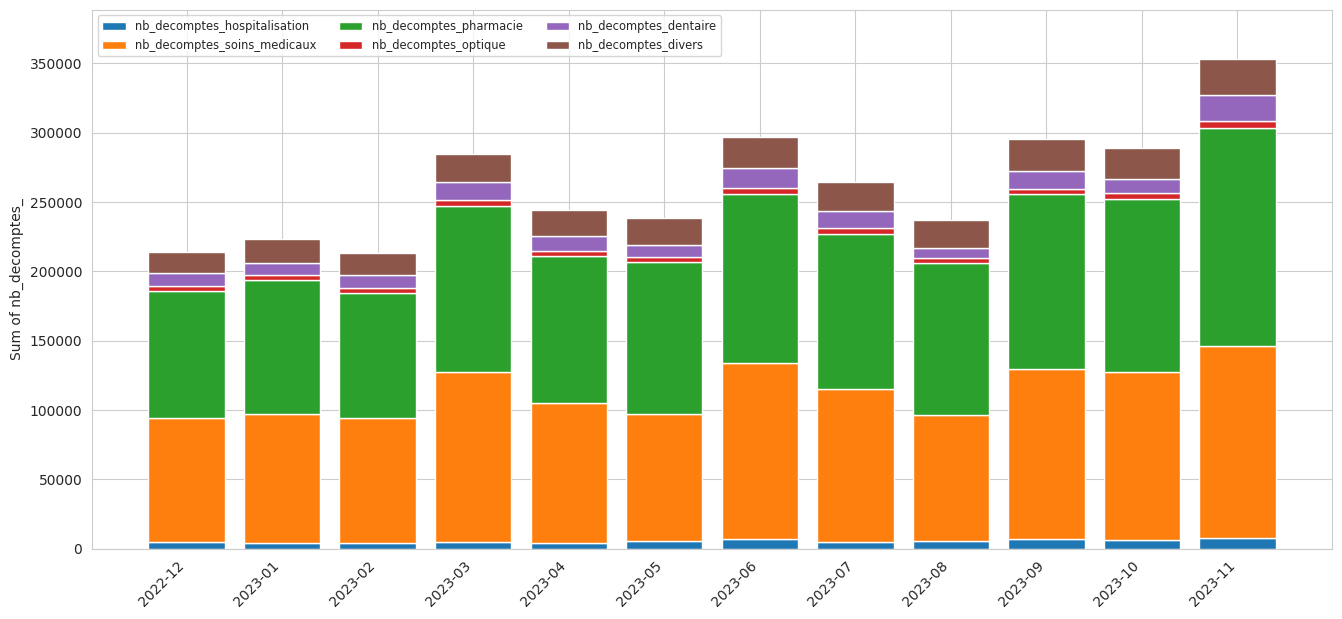

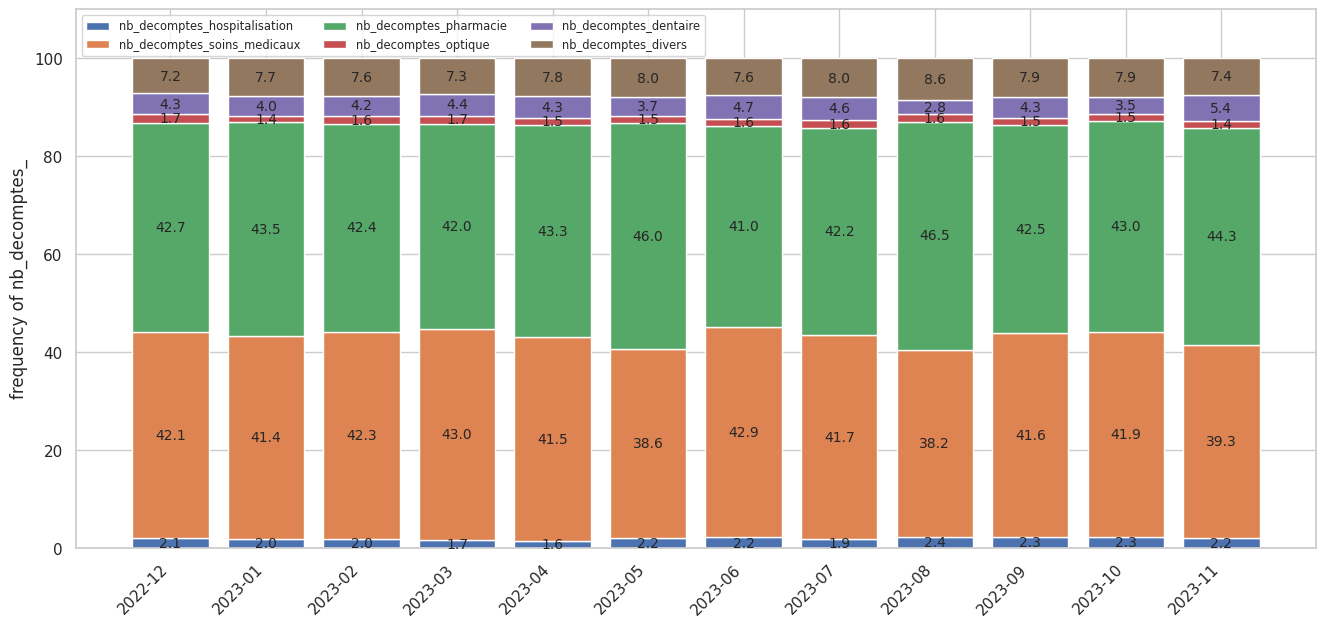

In [17]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='nb_decomptes_', x_axis_variable='month-year', type_stack='classic')

**Analysis of nombre de décomptes**
-   La distribution des décompte présente une certaine saisonnalité. On observe un pic à peu près tous les 3 mois.
-   Le mois de novembre est un mois particulièrement dense en termes de décompte : plusieurs raisons pourraient expliquer :
    -   Rendez-vous chez le médecin avant les vacances de Noël
    -   Effet rattrapage : accélération dossiers à traiter pour clôturer l'année
    -   etc.
-   Les décomptes pour pharmacie sont majoritaires dans notre jeu de données, et ce, quelque soit le mois. Ils sont suivi des soins médicaux.
-   En d'autres termes, les sollicitations Alptis concernent majoritairement (+ 80%) des actes de soins médicaux et de pharmacie.
-   Légère baisse de la proportion de décomptes pour soins médicaux en mai et en août et en novembre.

___

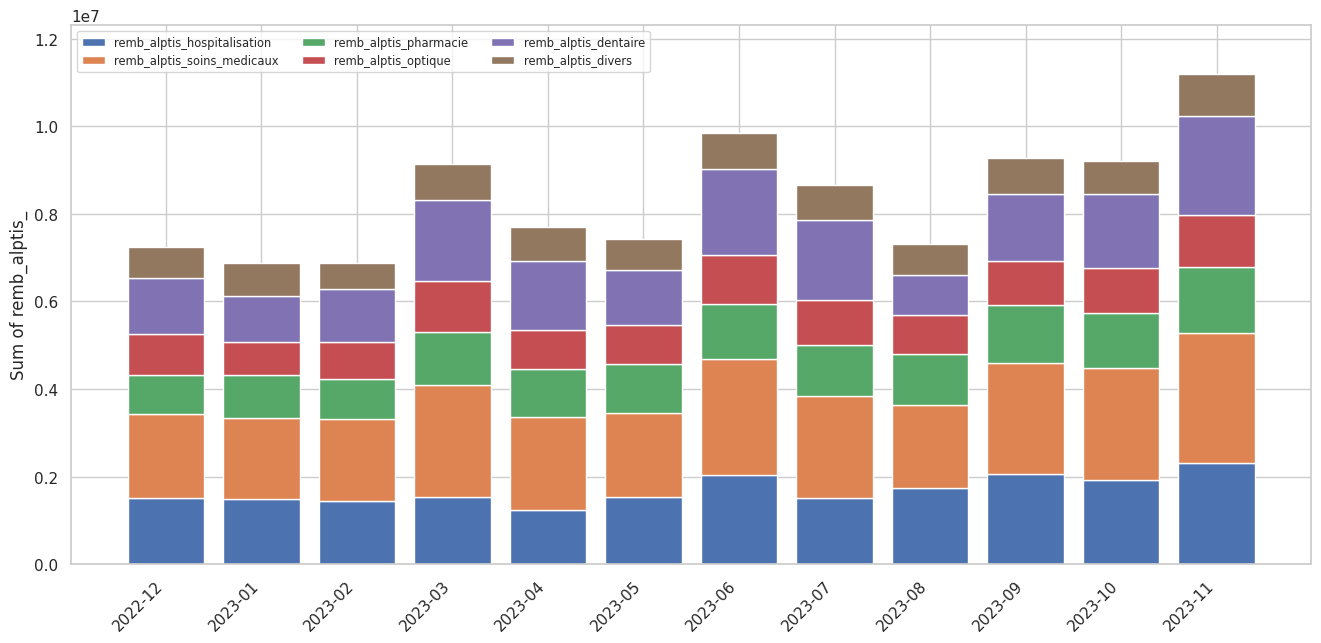

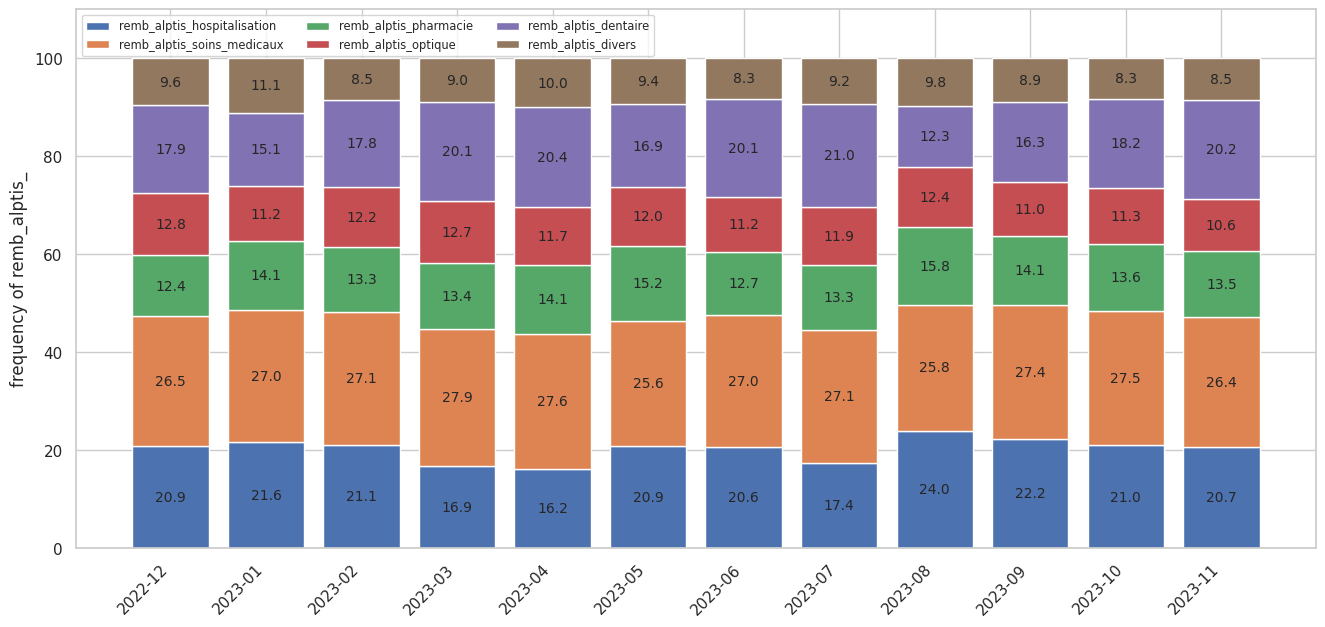

In [18]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='remb_alptis_', x_axis_variable='month-year', type_stack='classic')

**Analysis of remboursement par Alptis**

-   La distribution des remboursements est à peu près similaire à celle des décompte d'actes de santé, notamment au niveau des pics tous les trimestres et un mois de novembre relativement plus important.
-   Les hospitalisations qui ne représentent que 2% des décomptes réalisent 20% des remboursement. /!\ c'est u sujet à surveiller.
-   Les soins médicaux comptent pour un peu plus d'un quart des remboursements.
-   Pharmacie + optique = 1/4 - pas beaucoup

___

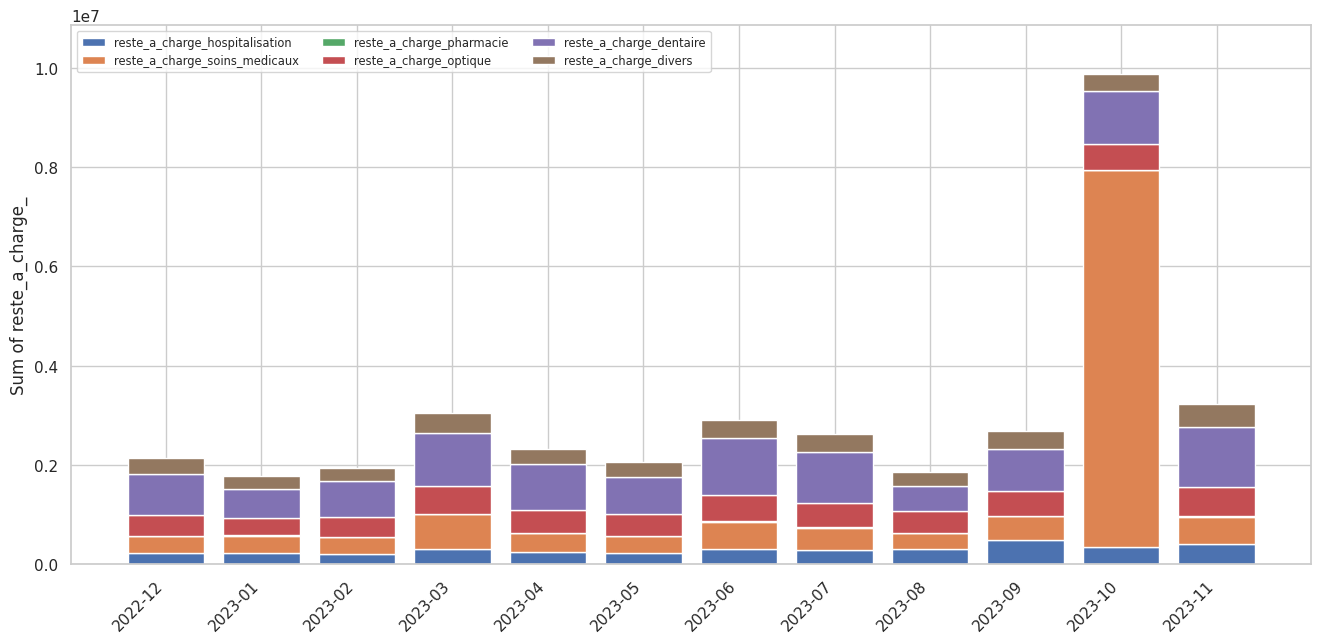

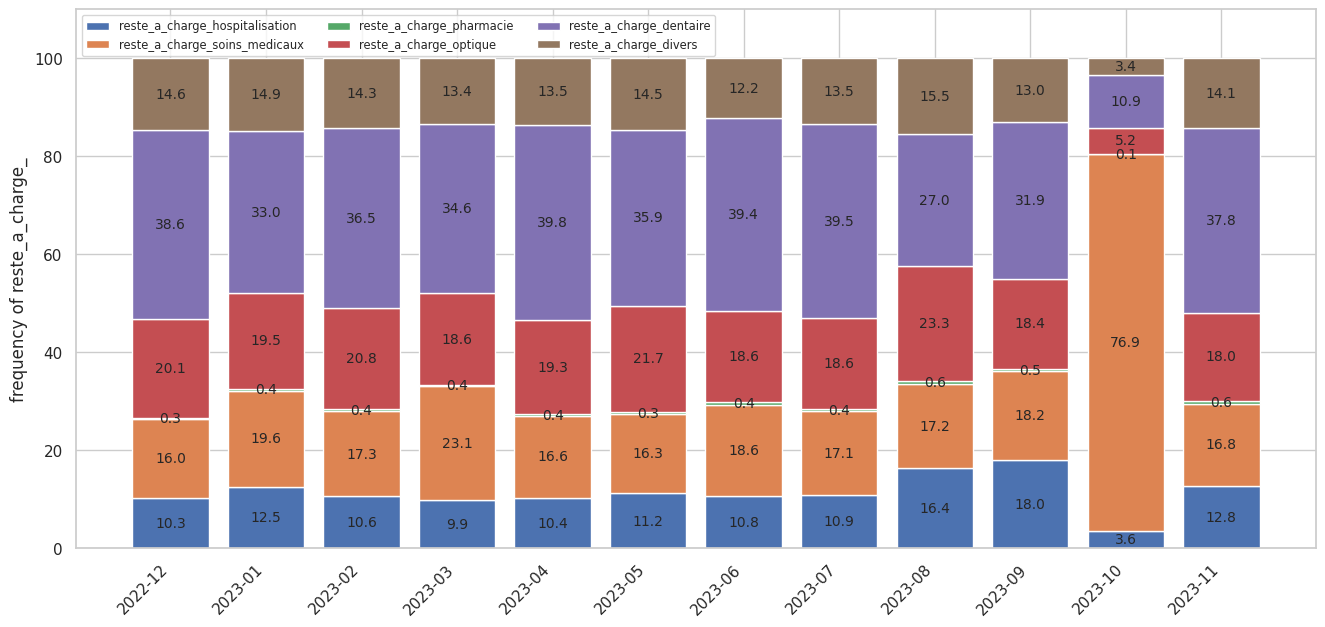

In [19]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='reste_a_charge_', x_axis_variable='month-year', type_stack='classic')

In [20]:
df_conso_test_octobre = df_consommations[['annee_mois_paiement','reste_a_charge_soins_medicaux']].groupby(by='annee_mois_paiement').agg(['sum', 'size', 'min', 'mean', 'max']).reset_index()
df_conso_test_octobre

annee_mois_paiement reste_a_charge_soins_medicaux                         \
                                                 sum   size  min       mean   
0           2022-12-31                     342327.72  61885  0.0   5.531675   
1           2023-01-31                     350373.22  65436  0.0   5.354441   
2           2023-02-28                     337183.67  66013  0.0   5.107837   
3           2023-03-31                     705284.24  75027  0.0   9.400406   
4           2023-04-30                     387535.24  73567  0.0   5.267786   
5           2023-05-31                     333911.40  74763  0.0   4.466265   
6           2023-06-30                     539347.68  81849  0.0   6.589545   
7           2023-07-31                     448322.66  80125  0.0   5.595291   
8           2023-08-31                     321581.12  77206  0.0   4.165235   
9           2023-09-30                     487411.05  84965  0.0   5.736610   
10          2023-10-31                    7589436.46  85482  0.0  88.784030   
11          2023-11-30                     540849.79  91514  0.0   5.910022   

                
           max  
0      1096.57  
1      2709.44  
2      1256.46  
3    220243.00  
4       802.14  
5      1631.85  
6     11538.11  
7      2738.74  
8      1920.84  
9      2352.99  
10  7092276.40  
11     3651.80

In [21]:
# Analysis of consommation on the
df_consommations[df_consommations['client_code']=='15760585'][['client_code', 'annee_mois_paiement', 'nb_decomptes_soins_medicaux', 'remb_alptis_soins_medicaux', 'remb_ro_soins_medicaux', 'reste_a_charge_soins_medicaux', 'frais_reels_soins_medicaux']]

,client_code,annee_mois_paiement,nb_decomptes_soins_medicaux,remb_alptis_soins_medicaux,remb_ro_soins_medicaux,reste_a_charge_soins_medicaux,frais_reels_soins_medicaux


In [22]:
df_portefeuille[df_portefeuille['client_code']=='15760585']

,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
115253,15760585,49,M,TNS,21000,21,nan,1.0,1,couple avec 1 enfant,...,nan,COURTIER CLASSIQUE,Sommeil,NaN,0,2,0,0,0,1


**Analysis of reste à charge**

-   Un montant anormalement élevé du reste à charge au mois d'octobre lié à un seul individu, dont les frais réels s'élèvent à +7 M€, avec 118 € de remboursement RO, et 180 € Alptis. Cette personne a résilié
-   Surveillance des Régimes Obligatoires spéciaux.
-   Les dépenses dentaires sont les actes où le reste à charge est le plus élevé. Compter 30 à 40% du reste à charge en fonction du mois.
-   Les soins médicaux comptent pour 20% à peu près
-   Les reste à charge en pharmacie sont très faibles (moins de 1%)

### Analyse discriminante

**Ancienneté de contrat et résiliation**

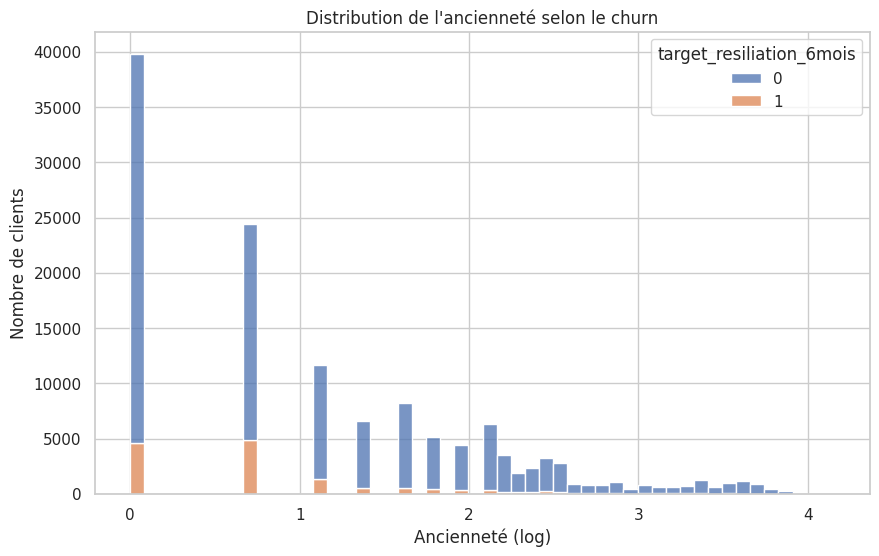

In [23]:
df = df_portefeuille.copy()
df["anciennete_log"] = np.log1p(df_portefeuille.client_anciennete_contrat_annees)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="anciennete_log",
    hue="target_resiliation_6mois",           # variable catégorielle
    bins=50,
    stat="count",          # fréquence
    multiple="stack",
)

plt.xlabel("Ancienneté (log)")
plt.ylabel("Nombre de clients")
plt.title("Distribution de l'ancienneté selon le churn")

plt.show()

**Evolution de la cotisation et résiliation**

In [24]:
df = df_portefeuille.copy()

# Calcul du taux de variation de la cotisation entre n+1 et n
df["n_plus_1_vs_n"] = ((df["client_cotisations_annualisees_n_plus1"]/df["client_cotisations_annualisees_n"])-1)*100

# Analyse de la distribution de ce taux de variation parmi les churn et les non churns
df[df["n_plus_1_vs_n"]>318][["client_code", "client_anciennete_contrat_annees", "client_age_souscripteur", "client_sexe_souscripteur", "client_cotisations_annualisees_n_plus1", "client_cotisations_annualisees_n"]]

,client_code,client_anciennete_contrat_annees,client_age_souscripteur,client_sexe_souscripteur,client_cotisations_annualisees_n_plus1,client_cotisations_annualisees_n
59835,13976698,3,64,M,2659,635.0


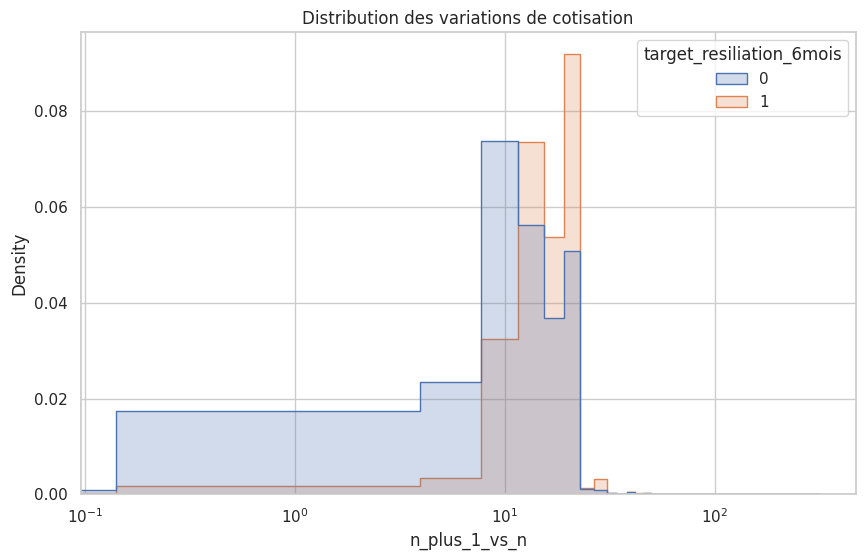

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="n_plus_1_vs_n",
    hue="target_resiliation_6mois",
    bins=100,
    stat="density",
    common_norm=False,
    element="step"
)

plt.axvline(0, linestyle="--")
plt.title("Distribution des variations de cotisation")
plt.xscale("log")

plt.show()

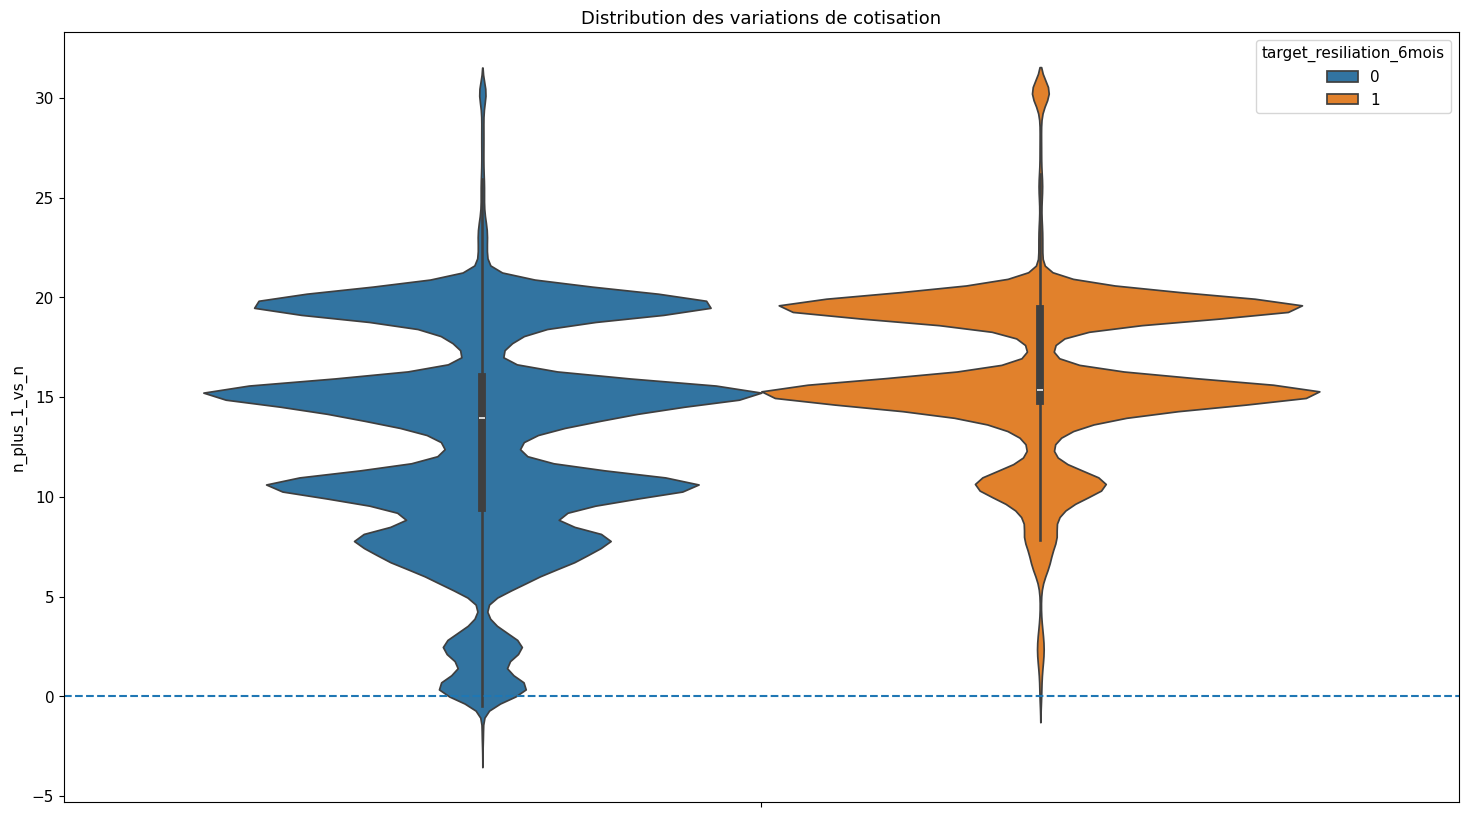

In [63]:
Q1 = df["n_plus_1_vs_n"].quantile(0.25)
Q3 = df["n_plus_1_vs_n"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_filtered = df[(df["n_plus_1_vs_n"] >= lower) & (df["n_plus_1_vs_n"] <= upper)]

plt.figure(figsize=(18,10))

sns.violinplot(
    data=df_filtered,
    hue="target_resiliation_6mois",
    y="n_plus_1_vs_n",
    inner="box",
)

plt.axhline(0, linestyle="--")
plt.title("Distribution des variations de cotisation")

plt.show()

**Consommation et résiliation**

/tmp/ipykernel_4124674/1068168057.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)


<Axes: xlabel='type_acte', ylabel='pct'>

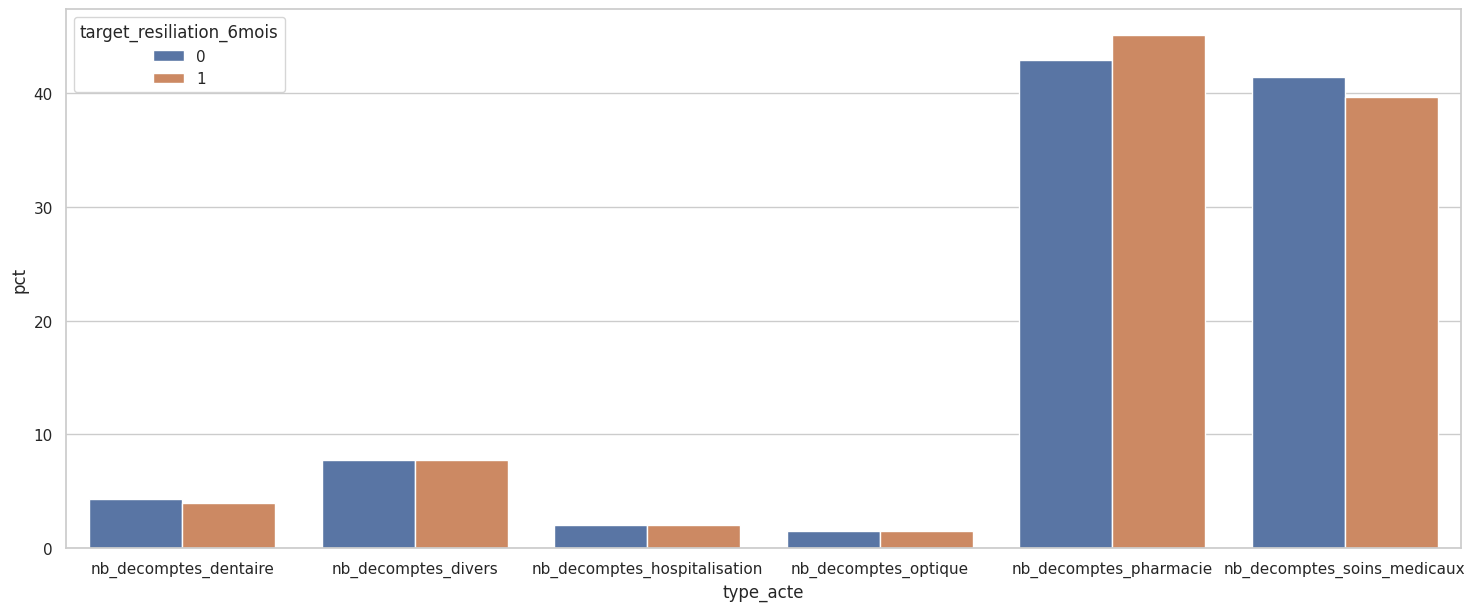

In [27]:
# Fusion Portefeuille et consommation (version de base) en termes de décompte
df_statut_churn = df_portefeuille[["client_code", "target_resiliation_6mois"]]
df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)
df_consommations["client_code"] = df_consommations["client_code"].astype(str)
central, left, right = TransformData.dataframe_merge(input_df1=df_statut_churn, input_df2=df_consommations, id_1="client_code", id_2="client_code")

cols = [
    "nb_decomptes_hospitalisation",
    "nb_decomptes_soins_medicaux",
    "nb_decomptes_pharmacie",
    "nb_decomptes_optique",
    "nb_decomptes_dentaire",
    "nb_decomptes_divers"
]

df_long = central.melt(
    id_vars=["target_resiliation_6mois"],
    value_vars=cols,
    var_name="type_acte",
    value_name="nb_actes"
)

# Agrégation
agg = (
    df_long
    .groupby(["target_resiliation_6mois", "type_acte"])["nb_actes"]
    .sum()
    .reset_index()
)

# Calcul de pourcentage sur ensemble de données brute
agg["pct"] = agg.groupby("target_resiliation_6mois")["nb_actes"].transform(lambda x: round(100*x / x.sum(), 2))

# Plot
plt.figure(figsize=(18,7))
sns.barplot(
    data= agg,
    x="type_acte",
    y="pct",
    hue="target_resiliation_6mois"
)

/tmp/ipykernel_4124674/3846705374.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)


<Axes: xlabel='type_acte', ylabel='pct'>

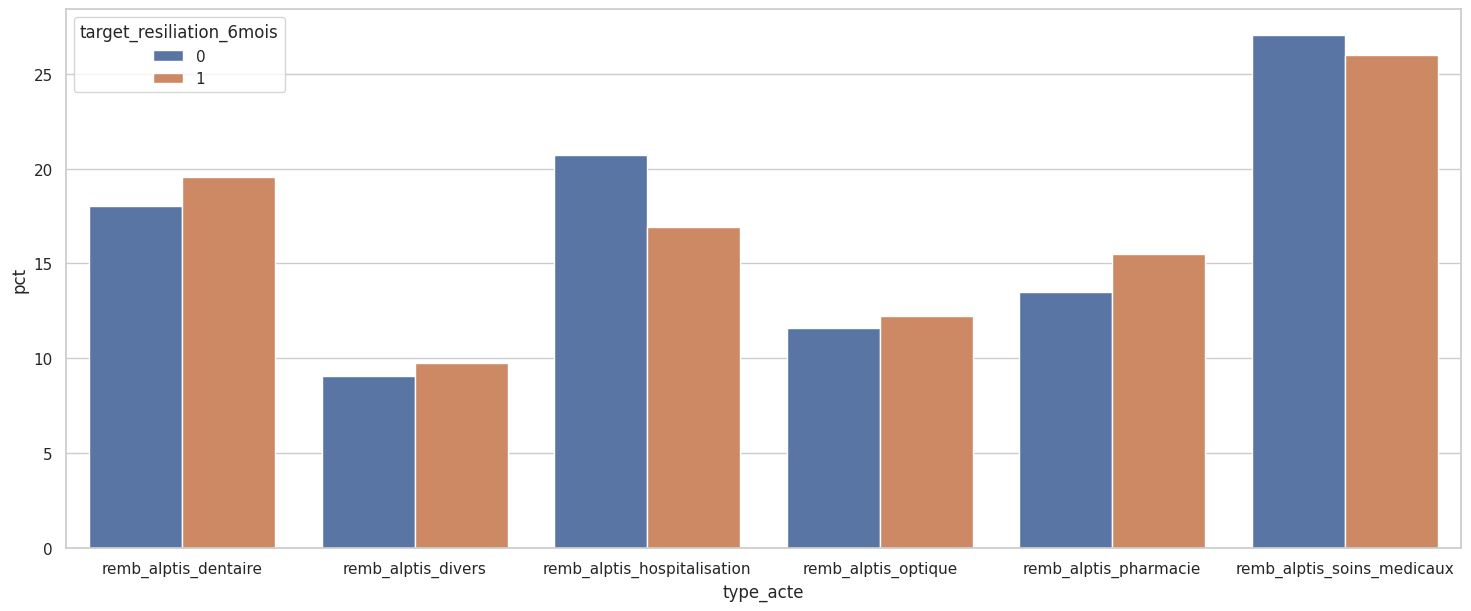

In [28]:
# Fusion Portefeuille et consommation (version de base) en termes de décompte
df_statut_churn = df_portefeuille[["client_code", "target_resiliation_6mois"]]
df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)
df_consommations["client_code"] = df_consommations["client_code"].astype(str)
central, left, right = TransformData.dataframe_merge(input_df1=df_statut_churn, input_df2=df_consommations, id_1="client_code", id_2="client_code")

cols = [
    "remb_alptis_hospitalisation",
    "remb_alptis_soins_medicaux",
    "remb_alptis_pharmacie",
    "remb_alptis_optique",
    "remb_alptis_dentaire",
    "remb_alptis_divers"
]

df_long = central.melt(
    id_vars=["target_resiliation_6mois"],
    value_vars=cols,
    var_name="type_acte",
    value_name="RAC_actes"
)

# Agrégation
agg = (
    df_long
    .groupby(["target_resiliation_6mois", "type_acte"])["RAC_actes"]
    .sum()
    .reset_index()
)

# Calcul de pourcentage sur ensemble de données brute
agg["pct"] = agg.groupby("target_resiliation_6mois")["RAC_actes"].transform(lambda x: round(100*x / x.sum(), 2))

# Plot
plt.figure(figsize=(18,7))
sns.barplot(
    data= agg,
    x="type_acte",
    y="pct",
    hue="target_resiliation_6mois"
)

/tmp/ipykernel_4124674/925895284.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)


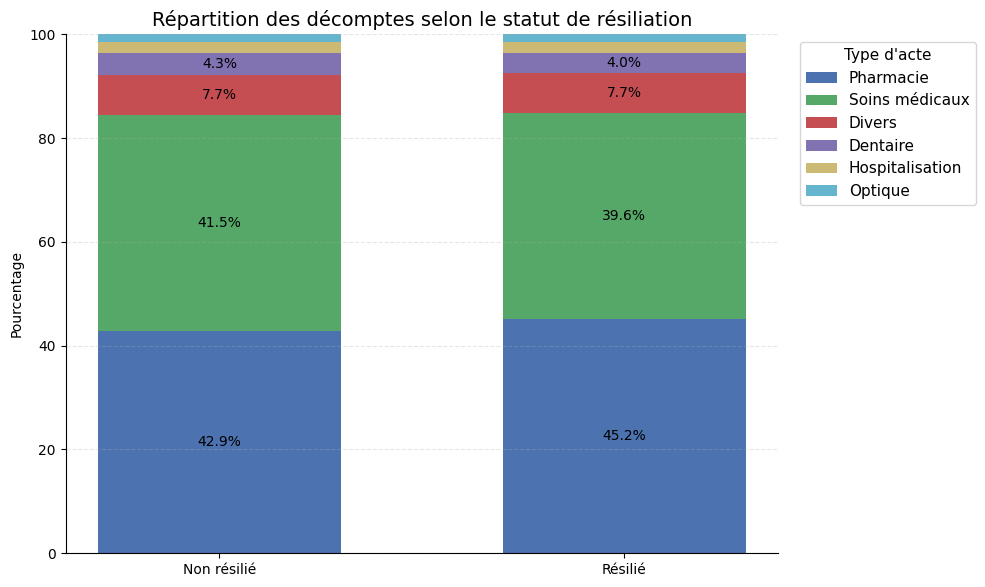

In [30]:
# Préparation des données - En fonction du nombre de décomptes

df_statut_churn = df_portefeuille[["client_code", "target_resiliation_6mois"]]
df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)
df_consommations["client_code"] = df_consommations["client_code"].astype(str)
central, left, right = TransformData.dataframe_merge(input_df1=df_statut_churn, input_df2=df_consommations, id_1="client_code", id_2="client_code")

cols = [
    "nb_decomptes_pharmacie",
    "nb_decomptes_soins_medicaux",
    "nb_decomptes_divers",
    "nb_decomptes_dentaire",
    "nb_decomptes_hospitalisation",
    "nb_decomptes_optique"
]

df_long = central.melt(
    id_vars=["target_resiliation_6mois"],
    value_vars=cols,
    var_name="type_acte",
    value_name="RAC_actes"
)

# Agrégation
agg = (
    df_long
    .groupby(["target_resiliation_6mois", "type_acte"])["RAC_actes"]
    .sum()
    .reset_index()
)

# Calcul de pourcentage sur ensemble de données brute
agg["pct"] = agg.groupby("target_resiliation_6mois")["RAC_actes"].transform(lambda x: round(100*x / x.sum(), 2))


# Pivot
df_pivot = agg.pivot(
    index="target_resiliation_6mois",
    columns="type_acte",
    values="pct"
)

# Ordre d'affichage
ordered_cols = [
    "nb_decomptes_pharmacie",
    "nb_decomptes_soins_medicaux",
    "nb_decomptes_divers",
    "nb_decomptes_dentaire",
    "nb_decomptes_hospitalisation",
    "nb_decomptes_optique"
]

df_pivot = df_pivot[ordered_cols]

# Labels plus propres
label_map = {
    "nb_decomptes_pharmacie": "Pharmacie",
    "nb_decomptes_soins_medicaux": "Soins médicaux",
    "nb_decomptes_divers": "Divers",
    "nb_decomptes_dentaire": "Dentaire",
    "nb_decomptes_hospitalisation": "Hospitalisation",
    "nb_decomptes_optique": "Optique"
}

colors = [
    "#4C72B0",  # bleu
    "#55A868",  # vert doux
    "#C44E52",  # rouge atténué
    "#8172B2",  # violet
    "#CCB974",  # beige
    "#64B5CD"   # bleu clair
]


fig, ax = plt.subplots(figsize=(10, 6))

plt.style.use("default")
ax.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

bottom = [0] * len(df_pivot.index)

for i, col in enumerate(df_pivot.columns):
    values = df_pivot[col].values
    
    bars = ax.bar(
        df_pivot.index,
        values,
        bottom=bottom,
        label=label_map[col],
        color=colors[i % len(colors)],
        width=0.6
    )
    
    # Ajouter les pourcentages au centre de chaque segment
    for j, (bar, val, btm) in enumerate(zip(bars, values, bottom)):
        if val >= 3:  # évite d'écrire sur les trop petits segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                btm + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )
    
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title("Répartition des décomptes selon le statut de résiliation", fontsize=14)
ax.set_ylabel("Pourcentage")
ax.set_xlabel("")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non résilié", "Résilié"])
ax.set_ylim(0, 100)

ax.legend(title="Type d'acte", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

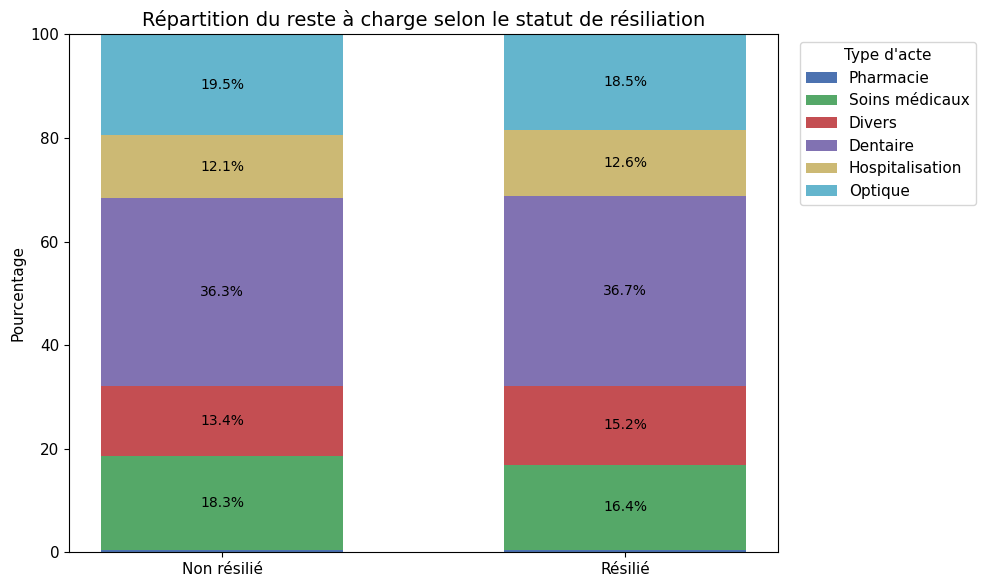

In [31]:
# Préparation des données - En fonction du reste à charge / On retire la valeur aberrante
df_portefeuille[df_portefeuille['client_code']=='15760585']
df_statut_churn = df_portefeuille[df_portefeuille['client_code']!='15760585'][["client_code", "target_resiliation_6mois"]]
df_statut_churn["client_code"] = df_statut_churn["client_code"].astype(str)
df_consommations["client_code"] = df_consommations["client_code"].astype(str)
central, left, right = TransformData.dataframe_merge(input_df1=df_statut_churn, input_df2=df_consommations, id_1="client_code", id_2="client_code")

cols = [
    "reste_a_charge_pharmacie",
    "reste_a_charge_soins_medicaux",
    "reste_a_charge_divers",
    "reste_a_charge_dentaire",
    "reste_a_charge_hospitalisation",
    "reste_a_charge_optique"
]

df_long = central.melt(
    id_vars=["target_resiliation_6mois"],
    value_vars=cols,
    var_name="type_acte",
    value_name="RAC_actes"
)

# Agrégation
agg = (
    df_long
    .groupby(["target_resiliation_6mois", "type_acte"])["RAC_actes"]
    .sum()
    .reset_index()
)

# Calcul de pourcentage sur ensemble de données brute
agg["pct"] = agg.groupby("target_resiliation_6mois")["RAC_actes"].transform(lambda x: round(100*x / x.sum(), 2))


# Pivot
df_pivot = agg.pivot(
    index="target_resiliation_6mois",
    columns="type_acte",
    values="pct"
)

# Ordre d'affichage
ordered_cols = [
    "reste_a_charge_pharmacie",
    "reste_a_charge_soins_medicaux",
    "reste_a_charge_divers",
    "reste_a_charge_dentaire",
    "reste_a_charge_hospitalisation",
    "reste_a_charge_optique"
]

df_pivot = df_pivot[ordered_cols]

# Labels plus propres
label_map = {
    "reste_a_charge_pharmacie": "Pharmacie",
    "reste_a_charge_soins_medicaux": "Soins médicaux",
    "reste_a_charge_divers": "Divers",
    "reste_a_charge_dentaire": "Dentaire",
    "reste_a_charge_hospitalisation": "Hospitalisation",
    "reste_a_charge_optique": "Optique"
}

colors = [
    "#4C72B0",  # bleu
    "#55A868",  # vert doux
    "#C44E52",  # rouge atténué
    "#8172B2",  # violet
    "#CCB974",  # beige
    "#64B5CD"   # bleu clair
]

plt.style.use("default")
ax.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})


fig, ax = plt.subplots(figsize=(10, 6))

bottom = [0] * len(df_pivot.index)

for i, col in enumerate(df_pivot.columns):
    values = df_pivot[col].values
    
    bars = ax.bar(
        df_pivot.index,
        values,
        bottom=bottom,
        label=label_map[col],
        color=colors[i % len(colors)],
        width=0.6
    )
    
    # Ajouter les pourcentages au centre de chaque segment
    for j, (bar, val, btm) in enumerate(zip(bars, values, bottom)):
        if val >= 3:  # évite d'écrire sur les trop petits segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                btm + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )
    
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title("Répartition du reste à charge selon le statut de résiliation", fontsize=14)
ax.set_ylabel("Pourcentage")
ax.set_xlabel("")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non résilié", "Résilié"])
ax.set_ylim(0, 100)

ax.legend(title="Type d'acte", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Segmentation des clients**

Les valeurs manquates : 0


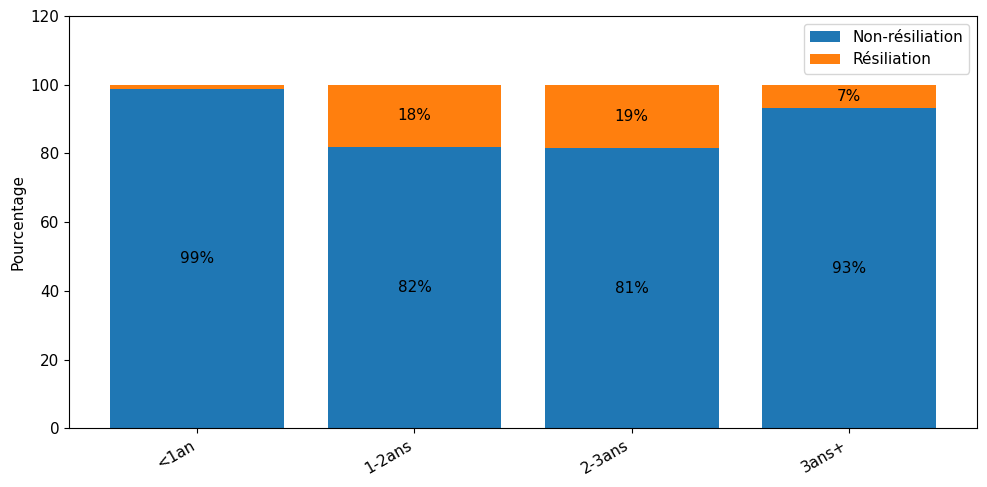

In [34]:
# Catégorisation suivant critère 1 : date de début de garantie
date_de_reference = pd.Timestamp("2024-05-31")
df["client_date_debut_effet_garantie"] = pd.to_datetime(df["client_date_debut_effet_garantie"])
df["anciennete_annee"] = (date_de_reference - df["client_date_debut_effet_garantie"]).dt.days/365.25

df["critere_1"] = pd.cut(
    df["anciennete_annee"],
    bins = [-0.01, 1, 2, 3, np.inf],
    labels=["<1an", "1-2ans", "2-3ans", "3ans+"],
    right=False
)
print(f"Les valeurs manquates : {df["critere_1"].isna().sum()}")
df["critere_1"].value_counts()

# Représentation de la segmentation par critère 1
seg_col = "critere_1"
target_col = "target_resiliation_6mois" 

## Table de contingence -> proportions par segment (ligne) -> %
tab = (
    pd.crosstab(df[seg_col], df[target_col], normalize="index")
    .rename(columns={0: "Non-résiliation", 1: "Résiliation"})
    .mul(100)
    .reset_index()
)

## plot empilé
x = tab[seg_col]
non = tab["Non-résiliation"]
res = tab["Résiliation"]

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x, non, label="Non-résiliation")
ax.bar(x, res, bottom=non, label="Résiliation")

ax.set_ylabel("Pourcentage")
ax.set_ylim(0, 120)
ax.legend()

for i, (a, b) in enumerate(zip(non, res)):
    if a > 3: ax.text(i, a/2, f"{a:.0f}%", ha="center", va="center")
    if b > 3: ax.text(i, a + b/2, f"{b:.0f}%", ha="center", va="center")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Résiliation avant la première année**

In [48]:
# Filtre sur la première année
df_annee_1 = df.copy()
df_annee_1 = df_annee_1[df_annee_1["critere_1"]=="<1an"]
print(f"Taille du dataset {df_annee_1.shape}")

Taille du dataset (14930, 50)


In [53]:
# Tableau des valeurs moyennes par variable selon le statut de churn ou pas
df_annee_1["courtier_est_escompte"] = pd.to_numeric(df_annee_1["courtier_est_escompte"], errors='coerce')
df_annee_1["client_est_contrat_madelin"] = df_annee_1["client_est_contrat_madelin"].astype(int)

cols = [
    "client_nb_assures_contrat",
    "client_est_contrat_madelin",
    "client_cotisations_annualisees_n",
    "client_cotisations_annualisees_n_plus1",
    "courtier_anciennete_annees",
    "courtier_est_escompte",
    "courtier_nb_affaires_n_moins1",
    "courtier_nb_affaires_n_moins2",
    "courtier_nb_radiations_n_moins1",
    "courtier_nb_radiations_n_moins2"
]

grouped = df_annee_1.groupby("target_resiliation_6mois")[cols]

mean = grouped.mean()
std = grouped.std()
count = grouped.count()

df_stats = pd.DataFrame({
    "nb_valeurs_valides": df_annee_1[cols].notna().sum(),
    "nb_classe_1": count.loc[1],
    "nb_classe_0": count.loc[0],
    "mean_classe_1": mean.loc[1],
    "mean_classe_0": mean.loc[0],
    "std_classe_1": std.loc[1],
    "std_classe_0": std.loc[0],
})

df_stats

,nb_valeurs_valides,nb_classe_1,nb_classe_0,mean_classe_1,mean_classe_0,std_classe_1,std_classe_0
client_nb_assures_contrat,14930,188,14742,1.537234,1.433998,0.615049,0.726731
client_est_contrat_madelin,14930,188,14742,0.021277,0.063085,0.144690,0.243124
client_cotisations_annualisees_n,14930,188,14742,1536.244681,1354.159408,698.179974,681.616381
client_cotisations_annualisees_n_plus1,14930,188,14742,1822.250000,1515.229345,846.515232,779.876131
courtier_anciennete_annees,14930,188,14742,6.808511,8.673993,5.981749,7.039420
courtier_est_escompte,14930,188,14742,0.542553,0.394994,0.499516,0.488866
courtier_nb_affaires_n_moins1,14930,188,14742,409.590426,525.076448,968.096488,1009.733038
courtier_nb_affaires_n_moins2,14930,188,14742,257.191489,383.679012,733.789174,786.618230
courtier_nb_radiations_n_moins1,14930,188,14742,193.686170,308.158594,549.748725,607.305790
courtier_nb_radiations_n_moins2,14930,188,14742,211.675532,335.217949,617.983460,676.975337


**Calcul des différences de comportements entre les personnes ayant résilié et ceux non dans la 2e et 3e année de contrat**

In [55]:
# Filtre sur les années 2 et 3
df_annee_2_3 = df.copy()
df_annee_2_3 = pd.concat([df_annee_2_3[df_annee_2_3["critere_1"]=="1-2ans"],df_annee_2_3[df_annee_2_3["critere_1"]=="2-3ans"]], axis=0)
print(f"Taille du dataset {df_annee_2_3.shape}")

Taille du dataset (55414, 50)


In [61]:
# Tableau des valeurs moyennes par variable selon le statut de churn ou pas
df_annee_2_3["courtier_est_escompte"] = pd.to_numeric(df_annee_2_3["courtier_est_escompte"], errors='coerce')
df_annee_2_3["client_est_contrat_madelin"] = df_annee_2_3["client_est_contrat_madelin"].astype(int)
df_annee_2_3["variation_cotisation_n_n1"] = round(100 * ((df_annee_2_3["client_cotisations_annualisees_n_plus1"]/df_annee_2_3["client_cotisations_annualisees_n"])-1) ,2)

cols = [
    "client_nb_assures_contrat",
    "client_est_contrat_madelin",
    "client_cotisations_annualisees_n",
    "client_cotisations_annualisees_n_plus1",
    "variation_cotisation_n_n1",
    "courtier_anciennete_annees",
    "courtier_est_escompte",
    "courtier_nb_affaires_n_moins1",
    "courtier_nb_affaires_n_moins2",
    "courtier_nb_radiations_n_moins1",
    "courtier_nb_radiations_n_moins2"
]

grouped = df_annee_2_3.groupby("target_resiliation_6mois")[cols]

mean = grouped.mean()
std = grouped.std()
count = grouped.count()
min = grouped.min()
max = grouped.max()

df_stats = pd.DataFrame({
    "nb_valeurs_valides": df_annee_2_3[cols].notna().sum(),
    "nb_classe_1": count.loc[1],
    "nb_classe_0": count.loc[0],
    # "min_classe_1": min.loc[1],
    # "max_classe_1": max.loc[1],
    # "min_classe_0": min.loc[0],
    # "max_classe_0": max.loc[0],
    "mean_classe_1": mean.loc[1],
    "mean_classe_0": mean.loc[0],
    "std_classe_1": std.loc[1],
    "std_classe_0": std.loc[0],
})

df_stats

,nb_valeurs_valides,nb_classe_1,nb_classe_0,mean_classe_1,mean_classe_0,std_classe_1,std_classe_0
client_nb_assures_contrat,55414,10099,45315,1.501535,1.449189,0.617203,0.713024
client_est_contrat_madelin,55414,10099,45315,0.030597,0.078186,0.172232,0.268467
client_cotisations_annualisees_n,55414,10099,45315,1507.620656,1362.513494,649.615310,690.080315
client_cotisations_annualisees_n_plus1,55414,10099,45315,1778.828300,1589.064747,777.496853,821.640668
variation_cotisation_n_n1,55414,10099,45315,17.740807,16.059390,5.127585,6.598754
courtier_anciennete_annees,55414,10099,45315,7.581642,9.598345,6.284670,7.275969
courtier_est_escompte,55414,10099,45315,0.552431,0.338519,0.497268,0.473211
courtier_nb_affaires_n_moins1,55414,10099,45315,412.040400,541.987863,756.164771,994.036893
courtier_nb_affaires_n_moins2,55414,10099,45315,248.288939,386.551385,596.051127,775.274522
courtier_nb_radiations_n_moins1,55414,10099,45315,178.131102,300.517687,435.628755,588.289634


/tmp/ipykernel_4124674/1736772216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_annee_2_3_filtered["log_cotisation"] = np.log1p(df_annee_2_3_filtered["client_cotisations_annualisees_n"])


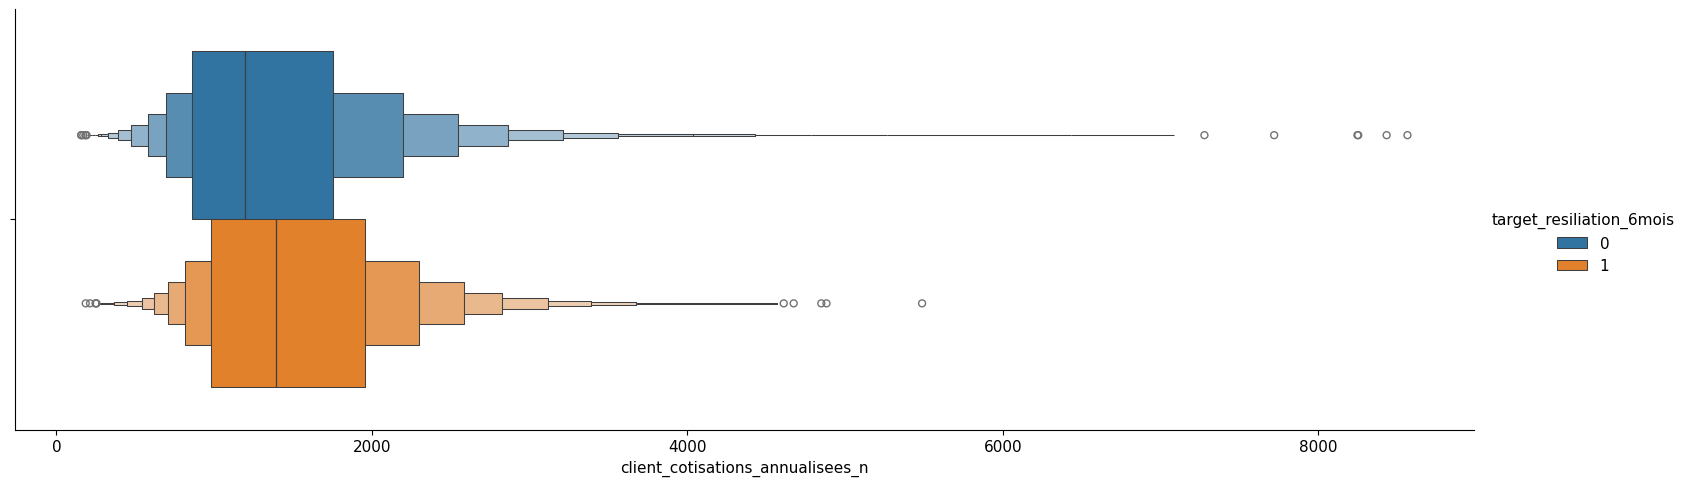

In [104]:
# Comparaisons des niveaux de citisation et de la variation de celles-ci
df_annee_2_3_filtered = df_annee_2_3[["client_cotisations_annualisees_n", "target_resiliation_6mois"]]
df_annee_2_3_filtered["log_cotisation"] = np.log1p(df_annee_2_3_filtered["client_cotisations_annualisees_n"])
sns.catplot(data=df_annee_2_3_filtered, x="client_cotisations_annualisees_n", hue="target_resiliation_6mois", kind="boxen", aspect=3)


In [105]:
# Comparaisons des niveaux de citisation et de la variation de celles-ci
stats = (
    df_annee_2_3_filtered
    .groupby("target_resiliation_6mois")["client_cotisations_annualisees_n"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        median="median",
        Q3=lambda x: x.quantile(0.75),
        mean="mean",
        std="std",
        count="count"
    )
)
stats

,Q1,median,Q3,mean,std,count
target_resiliation_6mois,,,,,,
0,859.0,1197.0,1752.0,1362.513494,690.080315,45315
1,982.5,1392.0,1956.0,1507.620656,649.615310,10099


In [ ]:
# Taux de churn par quartile de niveau de cotisation
df_taux_quartile = df_annee_2_3_filtered.copy()

df_taux_quartile["quartile_cotisation"] = pd.qcut(
    df_taux_quartile["client_cotisations_annualisees_n"],
    q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

churn_rate = (
    df_taux_quartile
    .groupby("quartile_cotisation")["target_resiliation_6mois"]
    .mean()
)

churn_rate

/tmp/ipykernel_4124674/2598433440.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quartile_cotisation")["target_resiliation_6mois"]


quartile_cotisation
Q1 (low)     0.125441
Q2           0.174601
Q3           0.199364
Q4 (high)    0.229758
Name: target_resiliation_6mois, dtype: float64

In [133]:
# Comparaisons de la variation des cotisations
df_annee_2_3_filtered = df_annee_2_3[["client_cotisations_annualisees_n", "variation_cotisation_n_n1", "target_resiliation_6mois"]]
df_annee_2_3_filtered["indicatrice_baisse"] =  (df_annee_2_3_filtered["variation_cotisation_n_n1"]<0)
df_annee_2_3_filtered[~df_annee_2_3_filtered["indicatrice_baisse"]].describe()

/tmp/ipykernel_4124674/3638663483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_annee_2_3_filtered["indicatrice_baisse"] =  (df_annee_2_3_filtered["variation_cotisation_n_n1"]<0)


,client_cotisations_annualisees_n,variation_cotisation_n_n1,target_resiliation_6mois
count,55356.000000,55356.000000,55356.000000
mean,1389.036039,16.396003,0.182383
std,684.730559,6.304638,0.386163
min,157.000000,0.000000,0.000000
25%,885.000000,14.760000,0.000000
50%,1229.000000,17.160000,0.000000
75%,1797.000000,19.450000,0.000000
max,8565.000000,313.190000,1.000000


In [136]:
# Taux de churn par quartile de variation de cotisation
df_taux_quartile = df_annee_2_3_filtered.copy()

df_taux_quartile["quartile_cotisation"] = pd.qcut(
    df_taux_quartile["variation_cotisation_n_n1"],
    q=4,
    #labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

churn_rate = (
    df_taux_quartile
    .groupby("quartile_cotisation")["target_resiliation_6mois"]
    .mean().reset_index()
)

churn_rate

/tmp/ipykernel_4124674/229871333.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quartile_cotisation")["target_resiliation_6mois"]


,quartile_cotisation,target_resiliation_6mois
0,"(-58.071, 14.75]",0.074829
1,"(14.75, 17.13]",0.253454
2,"(17.13, 19.45]",0.200858
3,"(19.45, 313.19]",0.200233


In [167]:
# Taux de résiliation selon bins prédéfinis
## On fait un clip des valeurs, i.e on assigne -100 à toutes les valeurs en dessous de -100 et 100 à toutes les valeurs au-dessus de 100

df_taux_bins = df_annee_2_3_filtered.copy()
df_taux_bins["variation_cotisation_n_n1"] = df_taux_bins["variation_cotisation_n_n1"].clip(-100,100)

bins = [-100, 0, 10, 15, 20, 100]

labels = [
    "baisse (<0%)",
    "hausse faible (0 à +10%)",
    "hausse modérée (+10 à +15%)",
    "hausse modérée (+15 à +20%)",
    "hausse forte (>+20%)"
]

df_taux_bins["variation_bin"] = pd.cut(
    df_taux_bins["variation_cotisation_n_n1"],
    bins=bins,
    labels=labels
)

churn_by_bin = (
    df_taux_bins
    .groupby("variation_bin")
    .agg(
        churn_rate=("target_resiliation_6mois", "mean"),
        avg_price = ("client_cotisations_annualisees_n", "mean"),
        count=("target_resiliation_6mois", "count")
    )
)

churn_by_bin["churn_rate"] = round(100 *churn_by_bin["churn_rate"],2)
churn_by_bin

/tmp/ipykernel_4124674/1149801118.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("variation_bin")


,churn_rate,avg_price,count
variation_bin,,,
baisse (<0%),5.08,1308.084746,59
hausse faible (0 à +10%),3.27,1062.258563,7182
hausse modérée (+10 à +15%),15.73,1221.079097,8774
hausse modérée (+15 à +20%),22.44,1467.083600,33098
hausse forte (>+20%),16.71,1585.488176,6301


<Axes: xlabel='variation_bin', ylabel='target_resiliation_6mois'>

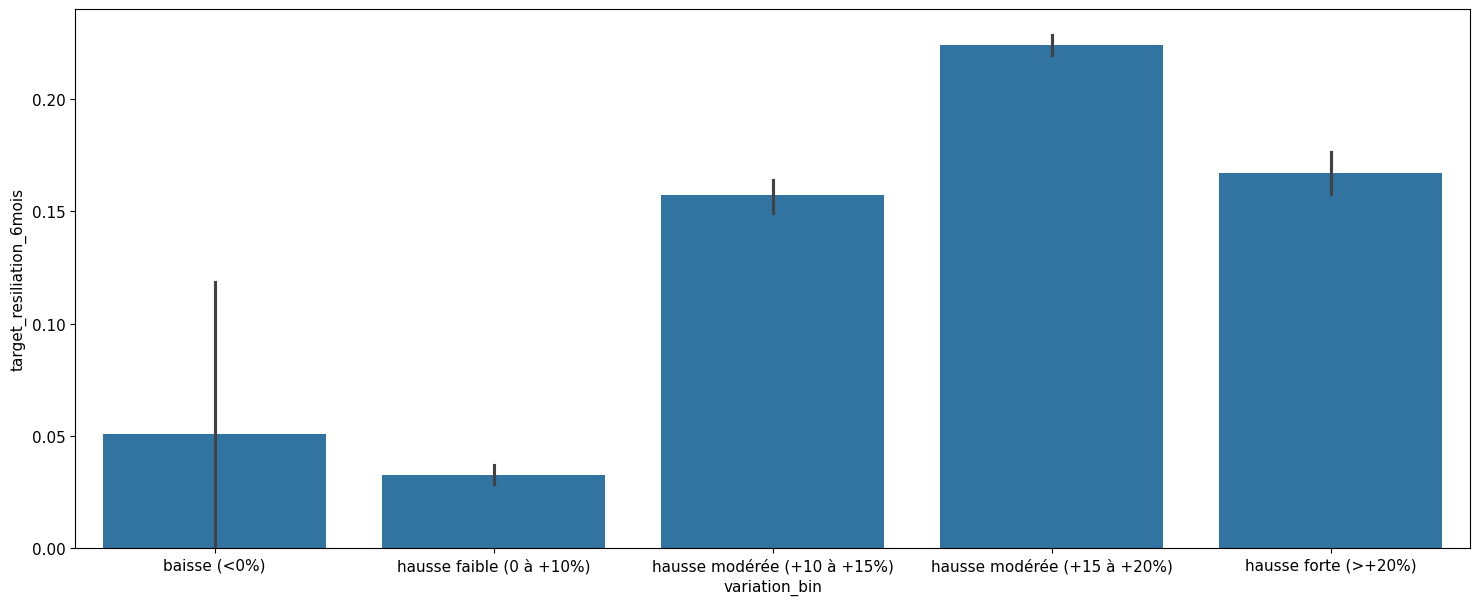

In [154]:
plt.figure(figsize=(18,7))
sns.barplot(
    data=df_taux_bins,
    x="variation_bin",
    y="target_resiliation_6mois"
)

In [150]:
# Taux de résiliation selon bins prédéfinis
## On fait un clip des valeurs, i.e on assigne -100 à toutes les valeurs en dessous de -100 et 100 à toutes les valeurs au-dessus de 100
## On applique un algorithme d'optimisation du binning à partir del la librairie optbinning
## Nécessite de downgrade ma version de scikit-learn


**Calcul des différences de comportements entre les personnes ayant résilié et ceux non dans à + 3ans de contrat**

In [161]:
# Filtre sur les années 2 et 3
df_annee_plus_3 = df.copy()
df_annee_plus_3 = df_annee_plus_3[df_annee_plus_3["critere_1"]=="3ans+"]
df_annee_plus_3["variation_cotisation_n_n1"] = round(100 * ((df_annee_plus_3["client_cotisations_annualisees_n_plus1"]/df_annee_plus_3["client_cotisations_annualisees_n"])-1) ,2)
print(f"Taille du dataset {df_annee_plus_3.shape}")

Taille du dataset (62232, 51)


/tmp/ipykernel_4124674/1552270390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_annee_plus_3_filtered["log_cotisation"] = np.log1p(df_annee_plus_3_filtered["client_cotisations_annualisees_n"])


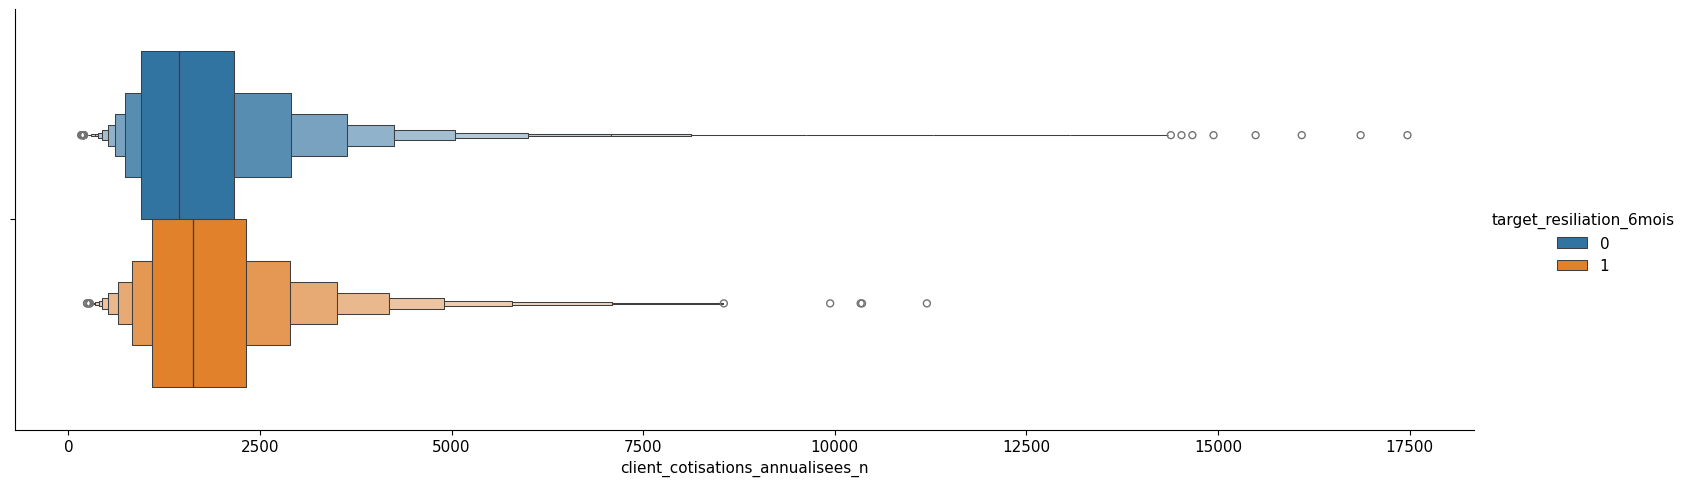

In [162]:
# Comparaisons des niveaux de citisation et de la variation de celles-ci
df_annee_plus_3_filtered = df_annee_plus_3[["client_cotisations_annualisees_n", "target_resiliation_6mois"]]
df_annee_plus_3_filtered["log_cotisation"] = np.log1p(df_annee_plus_3_filtered["client_cotisations_annualisees_n"])
sns.catplot(data=df_annee_plus_3_filtered, x="client_cotisations_annualisees_n", hue="target_resiliation_6mois", kind="boxen", aspect=3)

In [163]:
# Comparaisons des niveaux de citisation et de la variation de celles-ci
stats = (
    df_annee_plus_3_filtered
    .groupby("target_resiliation_6mois")["client_cotisations_annualisees_n"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        median="median",
        Q3=lambda x: x.quantile(0.75),
        mean="mean",
        std="std",
        count="count"
    )
)
stats

,Q1,median,Q3,mean,std,count
target_resiliation_6mois,,,,,,
0,942.0,1441.0,2160.0,1727.711171,1126.980316,58069
1,1092.5,1632.0,2317.0,1833.691809,1064.300260,4163


In [164]:
# Comparaisons de la variation des cotisations
df_annee_plus_3_filtered = df_annee_plus_3[["client_cotisations_annualisees_n", "variation_cotisation_n_n1", "target_resiliation_6mois"]]
df_annee_plus_3_filtered["indicatrice_baisse"] =  (df_annee_plus_3_filtered["variation_cotisation_n_n1"]<0)
df_annee_plus_3_filtered[~df_annee_plus_3_filtered["indicatrice_baisse"]].describe()

/tmp/ipykernel_4124674/1484956065.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_annee_plus_3_filtered["indicatrice_baisse"] =  (df_annee_plus_3_filtered["variation_cotisation_n_n1"]<0)


,client_cotisations_annualisees_n,variation_cotisation_n_n1,target_resiliation_6mois
count,62094.000000,62094.000000,62094.000000
mean,1735.616275,11.399886,0.066979
std,1123.742520,6.012364,0.249988
min,167.000000,0.000000,0.000000
25%,952.000000,8.890000,0.000000
50%,1454.000000,10.680000,0.000000
75%,2177.000000,14.290000,0.000000
max,17471.000000,318.740000,1.000000


In [166]:
# Taux de résiliation selon bins prédéfinis
## On fait un clip des valeurs, i.e on assigne -100 à toutes les valeurs en dessous de -100 et 100 à toutes les valeurs au-dessus de 100

df_taux_bins = df_annee_plus_3_filtered.copy()
df_taux_bins["variation_cotisation_n_n1"] = df_taux_bins["variation_cotisation_n_n1"].clip(-100,100)

bins = [-100, 0, 10, 15, 20, 100]

labels = [
    "baisse (<0%)",
    "hausse faible (0 à +10%)",
    "hausse modérée (+10 à +15%)",
    "hausse modérée (+15 à +20%)",
    "hausse forte (>+20%)"
]

df_taux_bins["variation_bin"] = pd.cut(
    df_taux_bins["variation_cotisation_n_n1"],
    bins=bins,
    labels=labels
)

churn_by_bin = (
    df_taux_bins
    .groupby("variation_bin")
    .agg(
        churn_rate=("target_resiliation_6mois", "mean"),
        avg_price = ("client_cotisations_annualisees_n", "mean"),
        count=("target_resiliation_6mois", "count")
    )
)

churn_by_bin["churn_rate"] = round(100 *churn_by_bin["churn_rate"],2)
churn_by_bin

/tmp/ipykernel_4124674/706366930.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("variation_bin")


,churn_rate,avg_price,count
variation_bin,,,
baisse (<0%),2.19,1243.069343,274
hausse faible (0 à +10%),3.02,1753.185682,20562
hausse modérée (+10 à +15%),7.18,1705.268729,29580
hausse modérée (+15 à +20%),12.29,1793.524599,10793
hausse forte (>+20%),8.50,1731.333333,1023


**Pourquoi on a autant de différence entre les contrats à plus de trois ans et les contrats entre 1 et 3 ans ?**

Questionner le nombre de décomptes de recours à Alptis suivant les contrats:

- Il y a peut-être une logique de on n'a pas d'antériorité sur les clients jeunes sur leur usage de nos services, vaut mieux suffisamment les taxer dès le départet pour couvrir le risque au maximum


In [184]:
# Nombre de décomptes selon la catégorisation des clients

## Récupération du dataset de portefeuille
df_clients_categories = df.copy()
df_clients_categories = pd.concat([df_clients_categories[df_clients_categories["critere_1"]=="1-2ans"],df_clients_categories[df_clients_categories["critere_1"]=="2-3ans"], df_clients_categories[df_clients_categories["critere_1"]=="3ans+"]], axis=0)
df_clients_categories = df_clients_categories[["client_code", "target_resiliation_6mois", "critere_1"]]
df_clients_categories["critere_1"] = df_clients_categories["critere_1"].map(
    {"1-2ans" : "1-3ans", "2-3ans" : "1-3ans", "3ans+" : "3ans+"}
)
print(f"Taille du dataset {df_clients_categories.shape}")

## Récupération du dataset de consommation
df_consommation_filtered = df_consommations.copy()
df_consommation_filtered = df_consommation_filtered[["client_code", "nb_decomptes", "remb_alptis"]]
df_consommation_filtered_grouped = df_consommation_filtered.groupby("client_code")[["nb_decomptes", "remb_alptis"]].sum().reset_index()


## Fusion des datasets
df_merged = pd.merge(left=df_clients_categories, right=df_consommation_filtered_grouped, on="client_code", how="left")
df_merged[["nb_decomptes", "remb_alptis"]].fillna(0)

print(f"Taille du dataset {df_merged.shape}")
df_merged

Taille du dataset (117646, 3)
Taille du dataset (117646, 5)


,client_code,target_resiliation_6mois,critere_1,nb_decomptes,remb_alptis
0,27119,0,1-3ans,81.0,8387.08
1,94158,0,1-3ans,29.0,743.95
2,98274,0,1-3ans,65.0,817.44
3,119806,0,1-3ans,15.0,157.33
4,126015,0,1-3ans,15.0,837.54
...,...,...,...,...,...
117641,14510749,0,3ans+,5.0,68.53
117642,14532365,0,3ans+,18.0,192.85
117643,14547233,0,3ans+,12.0,45.48
117644,14599761,0,3ans+,17.0,5705.87


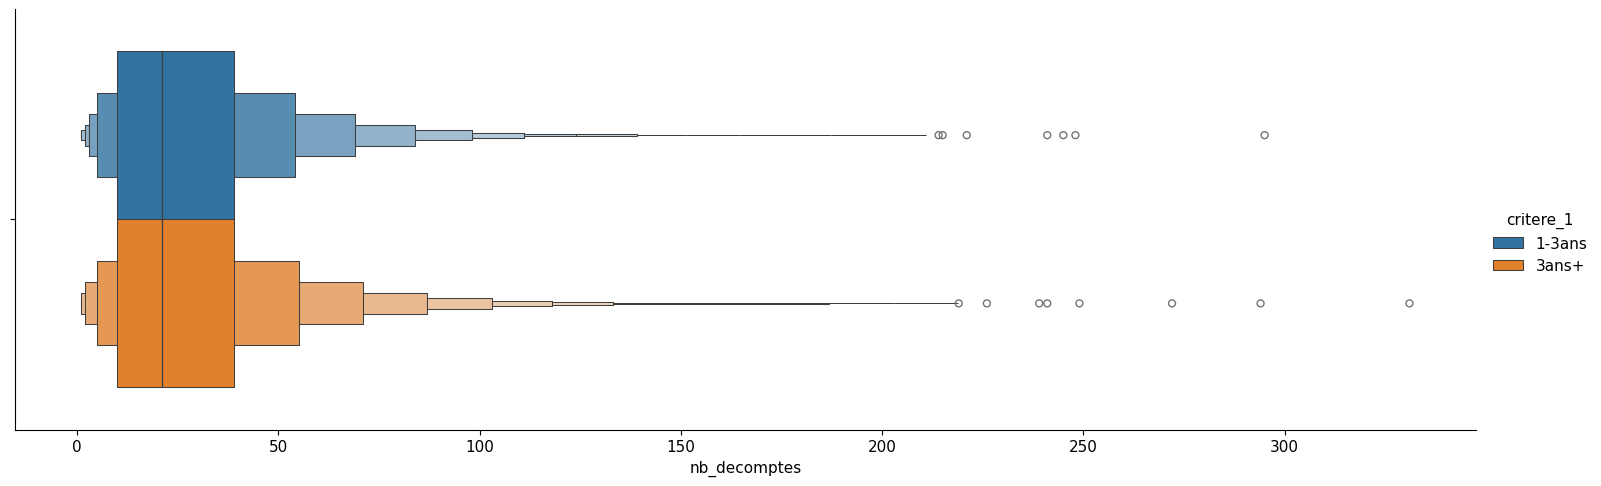

In [ ]:
# Comparaisons des niveaux de décomptes
df_merged_filtered = df_merged[["nb_decomptes", "critere_1"]]
sns.catplot(data=df_merged_filtered, x="nb_decomptes", hue="critere_1", kind="boxen", aspect=3)

In [185]:
# Comparaisons des niveaux de décomptes et de par ancienneté de contrat
# 
stats = (
    df_merged_filtered
    .groupby("critere_1")["nb_decomptes"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        median="median",
        Q3=lambda x: x.quantile(0.75),
        mean="mean",
        std="std",
        count="count"
    )
)
stats

,Q1,median,Q3,mean,std,count
critere_1,,,,,,
1-3ans,10.0,21.0,39.0,27.575926,23.590119,52090
3ans+,10.0,21.0,39.0,27.689367,24.753446,57708


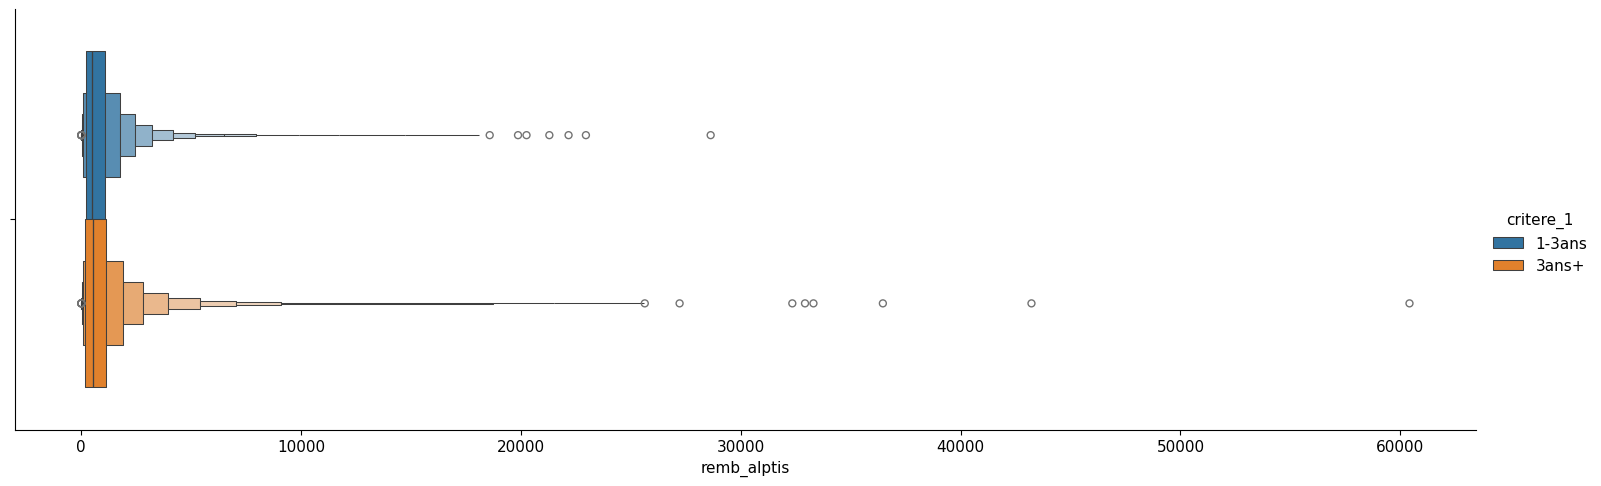

In [186]:
# Comparaisons des niveaux de remb
df_merged_filtered = df_merged[["remb_alptis", "critere_1"]]
sns.catplot(data=df_merged_filtered, x="remb_alptis", hue="critere_1", kind="boxen", aspect=3)

In [187]:
# Comparaisons des niveaux de remboursement et de par ancienneté de contrat
# 
stats = (
    df_merged_filtered
    .groupby("critere_1")["remb_alptis"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        median="median",
        Q3=lambda x: x.quantile(0.75),
        mean="mean",
        std="std",
        count="count"
    )
)
stats

,Q1,median,Q3,mean,std,count
critere_1,,,,,,
1-3ans,197.0175,498.595,1076.835,831.181704,1056.508976,52090
3ans+,191.9675,517.410,1141.850,933.042019,1409.483846,57708


/tmp/ipykernel_4124674/349902147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_filtered["log_remb_alptis"] = np.log1p(df_merged_filtered["remb_alptis"])
/tmp/ipykernel_4124674/349902147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_filtered["Contract tenure"] = df_merged_filtered["critere_1"]


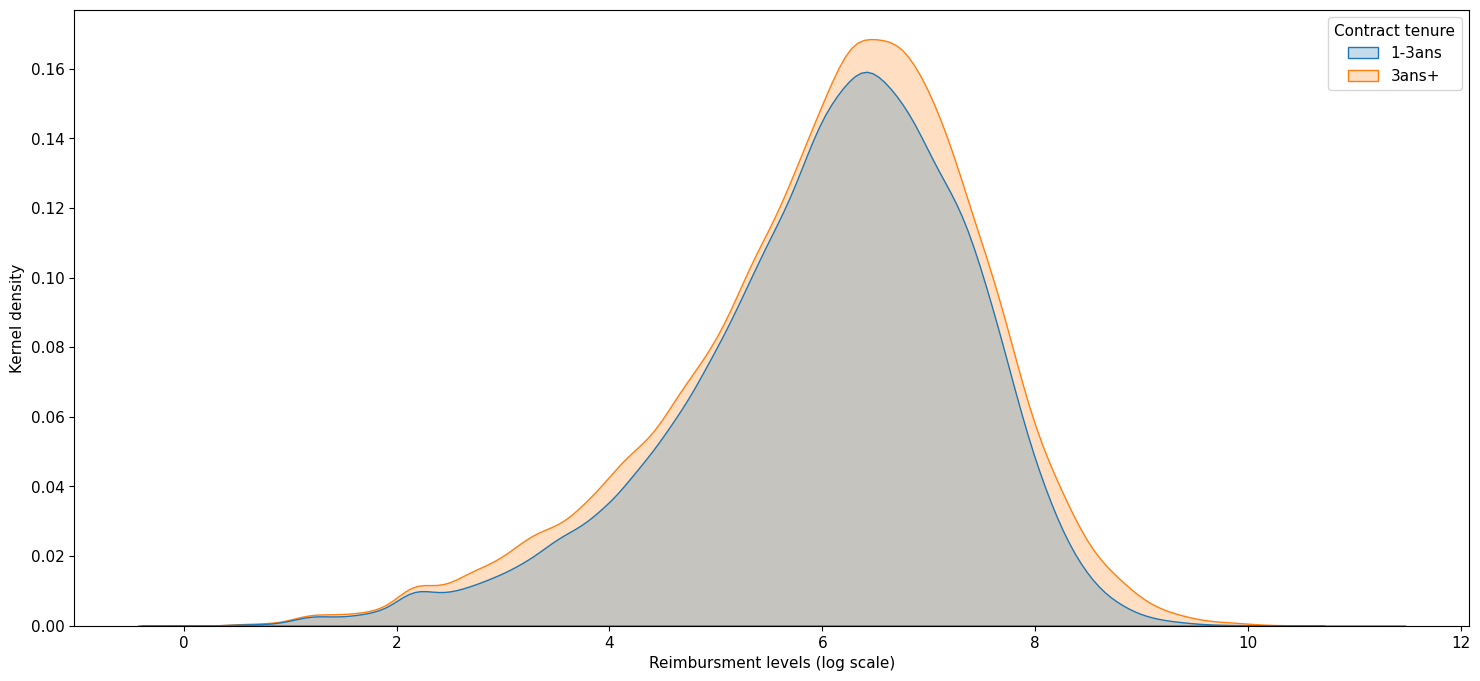

In [199]:
df_merged_filtered["log_remb_alptis"] = np.log1p(df_merged_filtered["remb_alptis"])
df_merged_filtered["Contract tenure"] = df_merged_filtered["critere_1"]
continuous_var= ["log_remb_alptis"]

plt.figure(figsize=(18, 8))
for c,var in enumerate(continuous_var):
  plt.subplot(1, 1, c+1)
  sns.kdeplot(data=df_merged_filtered, x=var, fill=var, hue='Contract tenure')
  #plt.title("Distribution of reimburs levels")
  plt.xlabel("Reimbursment levels (log scale)")
  plt.ylabel("Kernel density")